In [2]:
from multiagent_factcheck_5_enforcer import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="Results/G.csv"
)
df_res


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [4]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_Eval.csv"  # optional; sonst überschreibt er die Eingabe
)



📊 Evaluation (Final Verdict)
accuracy: 0.527
precision_true: 0.664
recall_true: 0.306
f1_true: 0.419
confusion_matrix:
[85, 193]
[43, 178]

Classification report:
              precision    recall  f1-score   support

        True       0.66      0.31      0.42       278
       False       0.48      0.81      0.60       221

    accuracy                           0.53       499
   macro avg       0.57      0.56      0.51       499
weighted avg       0.58      0.53      0.50       499

✅ CSV mit angehängter Evaluationszeile gespeichert unter: results/multiagent_results_5_enforcer_Eval.csv


In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# ===== Helper: Label-Normalisierung =====
def _normalize_labels(series: pd.Series):
    """Bringt Labels in {'True','False'}-Strings; ignoriert NaN."""
    return series.astype(str).str.strip().map(
        {"True": "True", "False": "False", "true": "True", "false": "False"}
    )

def compute_binary_metrics(df: pd.DataFrame, label_col: str, pred_col: str):
    y_true_all = _normalize_labels(df[label_col].dropna())
    y_pred_all = _normalize_labels(df[pred_col].dropna())
    idx = y_true_all.index.intersection(y_pred_all.index)
    y_true, y_pred = y_true_all.loc[idx], y_pred_all.loc[idx]

    if y_true.empty:
        return None

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_true": precision_score(y_true, y_pred, pos_label="True", zero_division=0),
        "recall_true": recall_score(y_true, y_pred, pos_label="True", zero_division=0),
        "f1_true": f1_score(y_true, y_pred, pos_label="True", zero_division=0),
        "n_eval": len(idx),
    }

# ===== Main =====
def evaluate_experts(csv_path: str):
    df = pd.read_csv(csv_path)

    # Alle Spalten finden, die mit "verdict_pred__" beginnen
    expert_cols = [c for c in df.columns if c.startswith("verdict_pred__")]
    results = []

    for col in expert_cols:
        metrics = compute_binary_metrics(df, "label_true", col)
        if metrics:
            results.append({
                "expert": col.replace("verdict_pred__", ""),
                **metrics
            })

    # Ergebnisse als DataFrame ausgeben
    results_df = pd.DataFrame(results)
    print("\n📊 Experten-Evaluation")
    print(results_df.to_string(index=False, float_format="%.3f"))
    return results_df

# ===== Beispielaufruf =====
if __name__ == "__main__":
    results_df = evaluate_experts("results/multiagent_results_5_enforcer.csv")



📊 Experten-Evaluation
        expert  accuracy  precision_true  recall_true  f1_true  n_eval
      politics     0.559           0.684        0.388    0.495     499
       economy     0.508           0.824        0.151    0.255     498
health_science     0.547           0.733        0.286    0.412     486
final_decision     0.527           0.664        0.306    0.419     499


# Fehlernanalyse

In [2]:
df_auswertung=pd.read_csv("results/multiagent_results_5_enforcer.csv")
df_original= pd.read_csv("own_datasets/preprocessed_test_cleaned.csv", sep="\t")

df_auswertung=pd.merge(df_auswertung, df_original, on="statement", how="inner")
df_auswertung

In [5]:
df_auswertung.drop("subjects", axis=1)

,label_true,statement,subject,verdict_pred__politics,explanation__politics,verdict_pred__economy,explanation__economy,verdict_pred__health_science,explanation__health_science,verdict_pred__final_decision,explanation__final_decision,verdict_final,explanation_final,label
0,True,Building a wall on the U.S . Mexico border wil...,immigration,True,"In 2017, President Trump signed Executive Orde...",True,According to the U.S. Customs and Border Prote...,True,According to a 2020 report by the U.S. Governm...,True,The construction of a border wall is a complex...,True,The construction of a border wall is a complex...,true
1,False,Wisconsin is on pace to double the number of l...,jobs,False,"According to the Bureau of Labor Statistics, W...",False,According to the Bureau of Labor Statistics (B...,False,There is no evidence to support the claim that...,False,"Experts from politics, economy, and health_sci...",False,"Experts from politics, economy, and health_sci...",false
2,False,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,John McCain has a long history of advocating f...,False,"According to the American Legion, a veterans s...",False,"John McCain, a former U.S. Senator, has a voti...",False,"Experts from politics, economy, and health_sci...",False,"Experts from politics, economy, and health_sci...",false
3,True,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,Suzanne Bonamici is a U.S. Representative from...,False,According to the 2020 Medicare Trustees Report...,False,There is no evidence to suggest that Suzanne B...,False,All experts agree that Suzanne Bonamici has no...,False,All experts agree that Suzanne Bonamici has no...,half-true
4,False,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",False,There is no credible evidence to support the c...,False,There is no credible evidence to support the c...,False,There is no scientific evidence to support the...,False,"Experts from politics, economy, and health_sci...",False,"Experts from politics, economy, and health_sci...",pants-fire
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,In one year (President Obama) provided $90 bil...,"candidates-biography,corporations,debates,ener...",True,"According to the U.S. Department of Energy, th...",False,The American Recovery and Reinvestment Act (AR...,True,"In 2009, the American Recovery and Reinvestmen...",True,The majority of experts agree that the America...,True,The majority of experts agree that the America...,false
496,True,Says that 98184 Texans are now driving with te...,"crime,elections,legal-issues",False,I couldn't find any information or credible so...,False,I couldn't find any reliable sources confirmin...,False,There is no credible evidence to support the c...,False,All experts agree that there is no credible ev...,False,All experts agree that there is no credible ev...,half-true
497,False,Youve been tremendously deceived by people who...,"corrections-and-updates,science,space",True,The Earth's spherical shape has been widely ac...,True,The overwhelming scientific consensus is that ...,True,The overwhelming scientific evidence supports ...,True,The overwhelming consensus among experts from ...,True,The overwhelming consensus among experts from ...,pants-fire
498,True,Jennifer Carrolls an outsider .,"candidates-biography,elections",False,Jennifer Carroll is a former Florida politicia...,False,Jennifer Carroll is a former Florida Deputy Se...,False,There is no credible evidence to support the c...,False,All experts agree that Jennifer Carroll is not...,False,All experts agree that Jennifer Carroll is not...,half-true


In [8]:
# Einheitlich in Kleinbuchstaben umwandeln und Leerzeichen entfernen
df_auswertung["label_true"] = df_auswertung["label_true"].astype(str).str.strip().str.lower()
df_auswertung["verdict_final"] = df_auswertung["verdict_final"].astype(str).str.strip().str.lower()

# Optional: Nur erlaubte Werte behalten
df_auswertung = df_auswertung[
    df_auswertung["label_true"].isin(["true", "false"]) &
    df_auswertung["verdict_final"].isin(["true", "false"])
]

# Jetzt neu berechnen
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("🔹 Binary Accuracy:", accuracy_score(df_auswertung["label_true"], df_auswertung["verdict_final"]))
print("\nConfusion Matrix:\n", confusion_matrix(df_auswertung["label_true"], df_auswertung["verdict_final"]))
print("\nClassification Report:\n", classification_report(df_auswertung["label_true"], df_auswertung["verdict_final"]))


🔹 Binary Accuracy: 0.5270541082164328

Confusion Matrix:
 [[178  43]
 [193  85]]

Classification Report:
               precision    recall  f1-score   support

       false       0.48      0.81      0.60       221
        true       0.66      0.31      0.42       278

    accuracy                           0.53       499
   macro avg       0.57      0.56      0.51       499
weighted avg       0.58      0.53      0.50       499



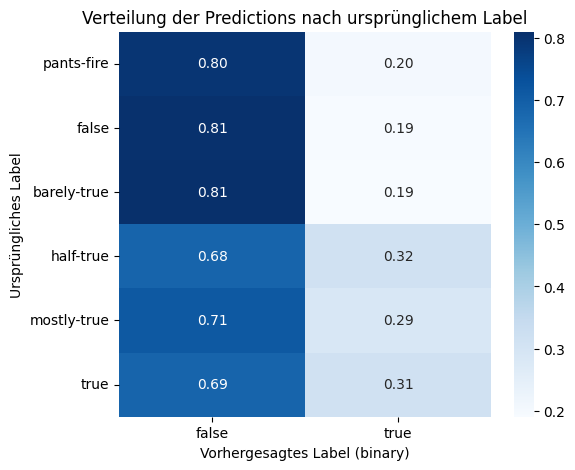

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Heatmap-Daten erstellen
cm = pd.crosstab(df_auswertung["label"], df_auswertung["verdict_final"], normalize="index")

# Reihenfolge manuell festlegen
order = ["pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"]

# Nur Labels übernehmen, die auch im DataFrame vorkommen
order = [lbl for lbl in order if lbl in cm.index]

# Heatmap neu sortieren
cm = cm.loc[order]

# Plotten
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt=".2f")
plt.title("Verteilung der Predictions nach ursprünglichem Label")
plt.xlabel("Vorhergesagtes Label (binary)")
plt.ylabel("Ursprüngliches Label")
plt.show()


In [25]:
errors = df_auswertung[df_auswertung["label_true"] != df_auswertung["verdict_final"]]
errors.groupby("label")["statement"].count()
errors.drop("subjects", axis=1)
errors.to_csv("results/multiagent_results_5_enforcer_model_misclassifications.tsv", sep="\t", index=False)

## unknown klasse

In [ ]:
from multiagent_factcheck_5_enforcer_unknown import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). "
            "If evidence is insufficient or ambiguous, output 'Unknown'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\",\"explanation\":\"2-4 concise sentences, "
            "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            "or not comparable, output 'Unknown'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\",\"explanation\":\"2-4 concise sentences, "
            "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). "
            "Distinguish correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output 'Unknown'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\",\"explanation\":\"2-4 concise sentences, "
            "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "If the majority view (weighted) is inconclusive, inconsistent, or poorly justified, choose 'Unknown'. "
        "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\",\"explanation\":\"2-4 concise sentences, "
        "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}



df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_unknown.csv"
)
df_res


E0000 00:00:1760184988.408932  121840 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760184988.415762  121840 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760184988.433593  121840 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760184988.433611  121840 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760184988.433614  121840 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760184988.433616  121840 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking:   0%|          | 0/500 [00:00<?, ?statement/s]

In [3]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1) CSV laden
csv_path = "results/multiagent_results_5_enforcer_unknown.csv"  # ggf. anpassen
df = pd.read_csv(csv_path)

# 2) Normalisieren
def norm(s):
    return (s.astype(str).str.strip().map({
        "True":"True","true":"True",
        "False":"False","false":"False",
        "Unknown":"Unknown","unknown":"Unknown",
        "None":"Unknown","none":"Unknown","nan":"Unknown"
    }))

y_true_all = norm(df["label_true"].dropna())
y_pred_all = norm(df["verdict_final"].dropna())
idx = y_true_all.index.intersection(y_pred_all.index)
y_true = y_true_all.loc[idx]
y_pred = y_pred_all.loc[idx]

# 3) Unknown-Analyse
unknown_mask = (y_pred == "Unknown")
unknown_count = int(unknown_mask.sum())
total = int(len(y_pred))
coverage = (total - unknown_count) / total if total else 0.0

print(f"🔎 Unknown-Predictions: {unknown_count} / {total} ({unknown_count/total*100:.1f}%)")
print(f"🧮 Coverage (pred ∈ {{True, False}}): {coverage*100:.1f}%")

# 4) Accuracy @ Covered + binärer Report
covered_mask = ~unknown_mask & y_pred.isin(["True","False"])
if covered_mask.any():
    y_true_cov = y_true[covered_mask]
    y_pred_cov = y_pred[covered_mask]
    acc_cov = accuracy_score(y_true_cov, y_pred_cov)
    print(f"\n✅ Accuracy@Covered: {acc_cov:.3f}")

    print("\n📋 Binary report (covered only):")
    print(classification_report(y_true_cov, y_pred_cov, labels=["True","False"], zero_division=0))

    print("Confusion matrix (covered only, rows=true, cols=pred):")
    print(pd.DataFrame(
        confusion_matrix(y_true_cov, y_pred_cov, labels=["True","False"]),
        index=["True","False"], columns=["True","False"]
    ))
else:
    print("\n⚠️ Keine Covered-Fälle (alle Unknown vorhergesagt).")

# 5) (Optional) Ternäre Sicht zur Vollständigkeit (GT binär, pred ternär)
labels_ter = ["True","False","Unknown"]
print("\nℹ️ Ternary report (incl. Unknown as prediction):")
print(classification_report(y_true, y_pred, labels=labels_ter, zero_division=0))

print("Ternary confusion (rows=true, cols=pred):")
print(pd.DataFrame(
    confusion_matrix(y_true, y_pred, labels=labels_ter),
    index=labels_ter, columns=labels_ter
))


🔎 Unknown-Predictions: 57 / 219 (26.0%)
🧮 Coverage (pred ∈ {True, False}): 74.0%

✅ Accuracy@Covered: 0.599

📋 Binary report (covered only):
              precision    recall  f1-score   support

        True       0.79      0.38      0.51        90
       False       0.53      0.88      0.66        72

    accuracy                           0.60       162
   macro avg       0.66      0.63      0.59       162
weighted avg       0.67      0.60      0.58       162

Confusion matrix (covered only, rows=true, cols=pred):
       True  False
True     34     56
False     9     63

ℹ️ Ternary report (incl. Unknown as prediction):
              precision    recall  f1-score   support

        True       0.79      0.28      0.41       123
       False       0.53      0.66      0.59        96
     Unknown       0.00      0.00      0.00         0

    accuracy                           0.44       219
   macro avg       0.44      0.31      0.33       219
weighted avg       0.68      0.44      0.49 

## finetuned majority vote

In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

# 1. CSV einlesen
# Pfad anpassen; falls dein CSV mit ; getrennt ist, sep=';' setzen
df = pd.read_csv("results/multiagent_results_5_enforcer_finetuned.csv")  # ggf. sep=';'

# 2. Nur relevante Spalten nutzen (Final-Decision-Agent explizit ignorieren)
expert_cols = [
    "verdict_pred__politics",
    "verdict_pred__economy",
    "verdict_pred__health_science",
]

label_col = "label_true"

# 3. Strings ("True"/"False") in echte Booleans umwandeln
def to_bool(series):
    return series.map({"True": True, "False": False, True: True, False: False})

df[label_col] = to_bool(df[label_col])
for c in expert_cols:
    df[c] = to_bool(df[c])

# 4. Majority Vote der Experten berechnen
# True, wenn mindestens 2 von 3 Experten True sind
df["majority_vote"] = (df[expert_cols].sum(axis=1) >= 2)

# 5. Metriken berechnen
y_true = df[label_col]
y_pred = df["majority_vote"]

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average="binary", pos_label=True
)
cm = confusion_matrix(y_true, y_pred)

print("=== Basis-Metriken (positives Label = True) ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}\n")

print("=== Confusion Matrix (True = 1, False = 0) ===")
print(cm)

print("\n=== Detaillierter Report ===")
print(classification_report(y_true, y_pred, target_names=["False", "True"]))


=== Basis-Metriken (positives Label = True) ===
Accuracy : 0.5960
Precision: 0.6570
Recall   : 0.5719
F1-Score : 0.6115

=== Confusion Matrix (True = 1, False = 0) ===
[[139  83]
 [119 159]]

=== Detaillierter Report ===
              precision    recall  f1-score   support

       False       0.54      0.63      0.58       222
        True       0.66      0.57      0.61       278

    accuracy                           0.60       500
   macro avg       0.60      0.60      0.60       500
weighted avg       0.60      0.60      0.60       500



## unknown 2

In [ ]:
from multiagent_factcheck_5_enforcer_unknown_1 import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). "
            "If evidence is insufficient or ambiguous, output 'Unknown'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\",\"explanation\":\"2-4 concise sentences, "
            "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            "or not comparable, output 'Unknown'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\",\"explanation\":\"2-4 concise sentences, "
            "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). "
            "Distinguish correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output 'Unknown'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\",\"explanation\":\"2-4 concise sentences, "
            "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "If the majority view (weighted) is inconclusive, inconsistent, or poorly justified, choose 'Unknown'. "
        "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\",\"explanation\":\"2-4 concise sentences, "
        "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}



df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_unknown_1.csv"
)
df_res


E0000 00:00:1762584298.742530  176508 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762584298.749240  176508 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762584298.767427  176508 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762584298.767444  176508 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762584298.767446  176508 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762584298.767448  176508 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking:   0%|          | 0/500 [00:00<?, ?statement/s]

In [2]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

def _normalize_labels(series: pd.Series) -> pd.Series:
    """Bringt Labels in {'True','False','Unknown'}; leere/none/nan -> 'Unknown'."""
    if series is None:
        return pd.Series([], dtype=object)
    s = series.astype(str).str.strip()
    s = s.replace({
        "": "Unknown", "none": "Unknown", "None": "Unknown",
        "nan": "Unknown", "NaN": "Unknown",
        "true": "True", "false": "False", "unknown": "Unknown"
    })
    return s


def evaluate_results(csv_path: str):
    """Lädt eine Ergebnis-CSV und führt ternäre & binäre Evaluation durch."""
    df = pd.read_csv(csv_path, dtype=str)
    print(f"✅ Datei geladen: {csv_path}")
    print(f"📊 Anzahl Zeilen: {len(df)}")

    if not {"label_true", "verdict_final"}.issubset(df.columns):
        raise ValueError("Fehlende Spalten: 'label_true' oder 'verdict_final'")

    # Normalisieren
    y_true = _normalize_labels(df["label_true"])
    y_pred = _normalize_labels(df["verdict_final"])

    # ---------- Ternary Evaluation (inkl. Unknown) ----------
    print("\n========== 📈 Ternary Evaluation (inkl. Unknown) ==========")
    labels = ["True", "False", "Unknown"]
    mask_tern = y_true.isin(labels) & y_pred.isin(labels)
    y_true_t = y_true[mask_tern]
    y_pred_t = y_pred[mask_tern]

    if len(y_true_t) > 0:
        acc_t = accuracy_score(y_true_t, y_pred_t)
        cm_t = confusion_matrix(y_true_t, y_pred_t, labels=labels)
        report_t = classification_report(y_true_t, y_pred_t, labels=labels, zero_division=0)
        print(f"n_eval: {len(y_true_t)}")
        print(f"accuracy: {acc_t:.3f}")
        print("confusion_matrix (rows=true, cols=pred):")
        for row in cm_t.tolist():
            print(row)
        print("Classification report:\n" + report_t)
    else:
        print("⚠️ Keine gültigen Zeilen für Ternary Evaluation gefunden.")

    # ---------- Binary Evaluation (Unknown ignorieren) ----------
    print("\n========== 📉 Binary Evaluation (Unknown ignoriert) ==========")
    mask_bin = y_true.isin({"True", "False"}) & y_pred.isin({"True", "False"})
    y_true_b = y_true[mask_bin]
    y_pred_b = y_pred[mask_bin]

    n_scored = len(y_true_b)
    n_ignored = len(df) - n_scored

    if n_scored > 0:
        acc = accuracy_score(y_true_b, y_pred_b)
        prec = precision_score(y_true_b, y_pred_b, pos_label="True", zero_division=0)
        rec = recall_score(y_true_b, y_pred_b, pos_label="True", zero_division=0)
        f1 = f1_score(y_true_b, y_pred_b, pos_label="True", zero_division=0)
        cm = confusion_matrix(y_true_b, y_pred_b, labels=["True", "False"]).tolist()
        report = classification_report(y_true_b, y_pred_b, labels=["True", "False"], zero_division=0)

        print(f"n_total: {len(df)} | n_scored: {n_scored} | n_ignored (Unknown): {n_ignored}")
        print(f"accuracy: {acc:.3f}")
        print(f"precision_true: {prec:.3f}")
        print(f"recall_true: {rec:.3f}")
        print(f"f1_true: {f1:.3f}")
        print("confusion_matrix (rows=true, cols=pred):")
        for row in cm:
            print(row)
        print("Classification report:\n" + report)
    else:
        print("⚠️ Keine (True/False)-Paare für Binary Evaluation vorhanden.")


if __name__ == "__main__":
    # 🔹 HIER DEINE DATEI EINTRAGEN 🔹
    csv_path = "results/multiagent_results_5_enforcer_unknown_1.csv"
    evaluate_results(csv_path)


✅ Datei geladen: results/multiagent_results_5_enforcer_unknown_1.csv
📊 Anzahl Zeilen: 500

========== 📈 Ternary Evaluation (inkl. Unknown) ==========
n_eval: 500
accuracy: 0.248
confusion_matrix (rows=true, cols=pred):
[34, 93, 151]
[12, 90, 120]
[0, 0, 0]
Classification report:
              precision    recall  f1-score   support

        True       0.74      0.12      0.21       278
       False       0.49      0.41      0.44       222
     Unknown       0.00      0.00      0.00         0

    accuracy                           0.25       500
   macro avg       0.41      0.18      0.22       500
weighted avg       0.63      0.25      0.31       500


========== 📉 Binary Evaluation (Unknown ignoriert) ==========
n_total: 500 | n_scored: 229 | n_ignored (Unknown): 271
accuracy: 0.541
precision_true: 0.739
recall_true: 0.268
f1_true: 0.393
confusion_matrix (rows=true, cols=pred):
[34, 93]
[12, 90]
Classification report:
              precision    recall  f1-score   support

        Tru

## unknown mit confidence

In [ ]:
from multiagent_factcheck_5_enforcer_unknown_1 import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "weight": 1.3,
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). "
            "If evidence is insufficient or ambiguous, output 'Unknown'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\","
            "\"explanation\":\"2-4 concise sentences, no stepwise reasoning or lists\","
            "\"confidence\": number between 0 and 1 (optional)}."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "weight": 1.0,
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            "or not comparable, output 'Unknown'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\","
            "\"explanation\":\"2-4 concise sentences, no stepwise reasoning or lists\","
            "\"confidence\": number between 0 and 1 (optional)}."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "weight": 1.2,
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). "
            "Distinguish correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output 'Unknown'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\","
            "\"explanation\":\"2-4 concise sentences, no stepwise reasoning or lists\","
            "\"confidence\": number between 0 and 1 (optional)}."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "If the majority view (weighted) is inconclusive, inconsistent, or poorly justified, choose 'Unknown'. "
        "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\","
        "\"explanation\":\"2-4 concise sentences, no stepwise reasoning or lists\","
        "\"confidence\": number between 0 and 1 (optional)}."
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}

df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_unknown_1_confidence.csv"
)

df_res.head()


E0000 00:00:1762668384.811382  177065 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762668384.818248  177065 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762668384.836267  177065 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762668384.836286  177065 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762668384.836289  177065 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762668384.836291  177065 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking:   0%|          | 2/500 [03:25<14:04:14, 101.72s/statement]

In [3]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

def _normalize_labels(series: pd.Series) -> pd.Series:
    """Bringt Labels in {'True','False','Unknown'}; leere/none/nan -> 'Unknown'."""
    if series is None:
        return pd.Series([], dtype=object)
    s = series.astype(str).str.strip()
    s = s.replace({
        "": "Unknown", "none": "Unknown", "None": "Unknown",
        "nan": "Unknown", "NaN": "Unknown",
        "true": "True", "false": "False", "unknown": "Unknown"
    })
    return s


def evaluate_results(csv_path: str):
    """Lädt eine Ergebnis-CSV und führt ternäre & binäre Evaluation durch."""
    df = pd.read_csv(csv_path, dtype=str)
    print(f"✅ Datei geladen: {csv_path}")
    print(f"📊 Anzahl Zeilen: {len(df)}")

    if not {"label_true", "verdict_final"}.issubset(df.columns):
        raise ValueError("Fehlende Spalten: 'label_true' oder 'verdict_final'")

    # Normalisieren
    y_true = _normalize_labels(df["label_true"])
    y_pred = _normalize_labels(df["verdict_final"])

    # ---------- Ternary Evaluation (inkl. Unknown) ----------
    print("\n========== 📈 Ternary Evaluation (inkl. Unknown) ==========")
    labels = ["True", "False", "Unknown"]
    mask_tern = y_true.isin(labels) & y_pred.isin(labels)
    y_true_t = y_true[mask_tern]
    y_pred_t = y_pred[mask_tern]

    if len(y_true_t) > 0:
        acc_t = accuracy_score(y_true_t, y_pred_t)
        cm_t = confusion_matrix(y_true_t, y_pred_t, labels=labels)
        report_t = classification_report(y_true_t, y_pred_t, labels=labels, zero_division=0)
        print(f"n_eval: {len(y_true_t)}")
        print(f"accuracy: {acc_t:.3f}")
        print("confusion_matrix (rows=true, cols=pred):")
        for row in cm_t.tolist():
            print(row)
        print("Classification report:\n" + report_t)
    else:
        print("⚠️ Keine gültigen Zeilen für Ternary Evaluation gefunden.")

    # ---------- Binary Evaluation (Unknown ignorieren) ----------
    print("\n========== 📉 Binary Evaluation (Unknown ignoriert) ==========")
    mask_bin = y_true.isin({"True", "False"}) & y_pred.isin({"True", "False"})
    y_true_b = y_true[mask_bin]
    y_pred_b = y_pred[mask_bin]

    n_scored = len(y_true_b)
    n_ignored = len(df) - n_scored

    if n_scored > 0:
        acc = accuracy_score(y_true_b, y_pred_b)
        prec = precision_score(y_true_b, y_pred_b, pos_label="True", zero_division=0)
        rec = recall_score(y_true_b, y_pred_b, pos_label="True", zero_division=0)
        f1 = f1_score(y_true_b, y_pred_b, pos_label="True", zero_division=0)
        cm = confusion_matrix(y_true_b, y_pred_b, labels=["True", "False"]).tolist()
        report = classification_report(y_true_b, y_pred_b, labels=["True", "False"], zero_division=0)

        print(f"n_total: {len(df)} | n_scored: {n_scored} | n_ignored (Unknown): {n_ignored}")
        print(f"accuracy: {acc:.3f}")
        print(f"precision_true: {prec:.3f}")
        print(f"recall_true: {rec:.3f}")
        print(f"f1_true: {f1:.3f}")
        print("confusion_matrix (rows=true, cols=pred):")
        for row in cm:
            print(row)
        print("Classification report:\n" + report)
    else:
        print("⚠️ Keine (True/False)-Paare für Binary Evaluation vorhanden.")


if __name__ == "__main__":
    # 🔹 HIER DEINE DATEI EINTRAGEN 🔹
    csv_path = "results/multiagent_results_5_enforcer_unknown_1_confidence.csv"
    evaluate_results(csv_path)


✅ Datei geladen: results/multiagent_results_5_enforcer_unknown_1_confidence.csv
📊 Anzahl Zeilen: 500

========== 📈 Ternary Evaluation (inkl. Unknown) ==========
n_eval: 500
accuracy: 0.232
confusion_matrix (rows=true, cols=pred):
[51, 63, 164]
[23, 65, 134]
[0, 0, 0]
Classification report:
              precision    recall  f1-score   support

        True       0.69      0.18      0.29       278
       False       0.51      0.29      0.37       222
     Unknown       0.00      0.00      0.00         0

    accuracy                           0.23       500
   macro avg       0.40      0.16      0.22       500
weighted avg       0.61      0.23      0.33       500


========== 📉 Binary Evaluation (Unknown ignoriert) ==========
n_total: 500 | n_scored: 202 | n_ignored (Unknown): 298
accuracy: 0.574
precision_true: 0.689
recall_true: 0.447
f1_true: 0.543
confusion_matrix (rows=true, cols=pred):
[51, 63]
[23, 65]
Classification report:
              precision    recall  f1-score   support



## nur experts unkown

In [ ]:
from multiagent_factcheck_5_enforcer_unknown_1 import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). "
            "If evidence is insufficient or ambiguous, output 'Unknown'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\",\"explanation\":\"2-4 concise sentences, "
            "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            "or not comparable, output 'Unknown'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\",\"explanation\":\"2-4 concise sentences, "
            "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). "
            "Distinguish correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output 'Unknown'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\",\"explanation\":\"2-4 concise sentences, "
            "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]


decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_unknown_1_only_experts.csv"
)
df_res


E0000 00:00:1762765354.502620  177760 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762765354.509721  177760 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762765354.528376  177760 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762765354.528400  177760 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762765354.528402  177760 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762765354.528404  177760 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking:   0%|          | 0/500 [00:00<?, ?statement/s]

In [3]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

def _normalize_labels(series: pd.Series) -> pd.Series:
    """Bringt Labels in {'True','False','Unknown'}; leere/none/nan -> 'Unknown'."""
    if series is None:
        return pd.Series([], dtype=object)
    s = series.astype(str).str.strip()
    s = s.replace({
        "": "Unknown", "none": "Unknown", "None": "Unknown",
        "nan": "Unknown", "NaN": "Unknown",
        "true": "True", "false": "False", "unknown": "Unknown"
    })
    return s


def evaluate_results(csv_path: str):
    """Lädt eine Ergebnis-CSV und führt ternäre & binäre Evaluation durch."""
    df = pd.read_csv(csv_path, dtype=str)
    print(f"✅ Datei geladen: {csv_path}")
    print(f"📊 Anzahl Zeilen: {len(df)}")

    if not {"label_true", "verdict_final"}.issubset(df.columns):
        raise ValueError("Fehlende Spalten: 'label_true' oder 'verdict_final'")

    # Normalisieren
    y_true = _normalize_labels(df["label_true"])
    y_pred = _normalize_labels(df["verdict_final"])

    # ---------- Ternary Evaluation (inkl. Unknown) ----------
    print("\n========== 📈 Ternary Evaluation (inkl. Unknown) ==========")
    labels = ["True", "False", "Unknown"]
    mask_tern = y_true.isin(labels) & y_pred.isin(labels)
    y_true_t = y_true[mask_tern]
    y_pred_t = y_pred[mask_tern]

    if len(y_true_t) > 0:
        acc_t = accuracy_score(y_true_t, y_pred_t)
        cm_t = confusion_matrix(y_true_t, y_pred_t, labels=labels)
        report_t = classification_report(y_true_t, y_pred_t, labels=labels, zero_division=0)
        print(f"n_eval: {len(y_true_t)}")
        print(f"accuracy: {acc_t:.3f}")
        print("confusion_matrix (rows=true, cols=pred):")
        for row in cm_t.tolist():
            print(row)
        print("Classification report:\n" + report_t)
    else:
        print("⚠️ Keine gültigen Zeilen für Ternary Evaluation gefunden.")

    # ---------- Binary Evaluation (Unknown ignorieren) ----------
    print("\n========== 📉 Binary Evaluation (Unknown ignoriert) ==========")
    mask_bin = y_true.isin({"True", "False"}) & y_pred.isin({"True", "False"})
    y_true_b = y_true[mask_bin]
    y_pred_b = y_pred[mask_bin]

    n_scored = len(y_true_b)
    n_ignored = len(df) - n_scored

    if n_scored > 0:
        acc = accuracy_score(y_true_b, y_pred_b)
        prec = precision_score(y_true_b, y_pred_b, pos_label="True", zero_division=0)
        rec = recall_score(y_true_b, y_pred_b, pos_label="True", zero_division=0)
        f1 = f1_score(y_true_b, y_pred_b, pos_label="True", zero_division=0)
        cm = confusion_matrix(y_true_b, y_pred_b, labels=["True", "False"]).tolist()
        report = classification_report(y_true_b, y_pred_b, labels=["True", "False"], zero_division=0)

        print(f"n_total: {len(df)} | n_scored: {n_scored} | n_ignored (Unknown): {n_ignored}")
        print(f"accuracy: {acc:.3f}")
        print(f"precision_true: {prec:.3f}")
        print(f"recall_true: {rec:.3f}")
        print(f"f1_true: {f1:.3f}")
        print("confusion_matrix (rows=true, cols=pred):")
        for row in cm:
            print(row)
        print("Classification report:\n" + report)
    else:
        print("⚠️ Keine (True/False)-Paare für Binary Evaluation vorhanden.")


if __name__ == "__main__":
    # 🔹 HIER DEINE DATEI EINTRAGEN 🔹
    csv_path = "results/multiagent_results_5_enforcer_unknown_1_only_experts.csv"
    evaluate_results(csv_path)


✅ Datei geladen: results/multiagent_results_5_enforcer_unknown_1_only_experts.csv
📊 Anzahl Zeilen: 500

========== 📈 Ternary Evaluation (inkl. Unknown) ==========
n_eval: 500
accuracy: 0.446
confusion_matrix (rows=true, cols=pred):
[57, 168, 53]
[16, 166, 40]
[0, 0, 0]
Classification report:
              precision    recall  f1-score   support

        True       0.78      0.21      0.32       278
       False       0.50      0.75      0.60       222
     Unknown       0.00      0.00      0.00         0

    accuracy                           0.45       500
   macro avg       0.43      0.32      0.31       500
weighted avg       0.65      0.45      0.45       500


========== 📉 Binary Evaluation (Unknown ignoriert) ==========
n_total: 500 | n_scored: 407 | n_ignored (Unknown): 93
accuracy: 0.548
precision_true: 0.781
recall_true: 0.253
f1_true: 0.383
confusion_matrix (rows=true, cols=pred):
[57, 168]
[16, 166]
Classification report:
              precision    recall  f1-score   suppor

### versuch 2

In [ ]:
from multiagent_factcheck_5_enforcer_unknown_only_experts import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). "
            "If evidence is insufficient or ambiguous, output 'Unknown'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\",\"explanation\":\"2-4 concise sentences, "
            "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            "or not comparable, output 'Unknown'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\",\"explanation\":\"2-4 concise sentences, "
            "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). "
            "Distinguish correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output 'Unknown'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False|Unknown\",\"explanation\":\"2-4 concise sentences, "
            "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]


decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_unknown_1_only_experts.csv"
)
df_res


In [1]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

def _normalize_labels(series: pd.Series) -> pd.Series:
    """Bringt Labels in {'True','False','Unknown'}; leere/none/nan -> 'Unknown'."""
    if series is None:
        return pd.Series([], dtype=object)
    s = series.astype(str).str.strip()
    s = s.replace({
        "": "Unknown", "none": "Unknown", "None": "Unknown",
        "nan": "Unknown", "NaN": "Unknown",
        "true": "True", "false": "False", "unknown": "Unknown"
    })
    return s


def evaluate_results(csv_path: str):
    """Lädt eine Ergebnis-CSV und führt ternäre & binäre Evaluation durch."""
    df = pd.read_csv(csv_path, dtype=str)
    print(f"✅ Datei geladen: {csv_path}")
    print(f"📊 Anzahl Zeilen: {len(df)}")

    if not {"label_true", "verdict_final"}.issubset(df.columns):
        raise ValueError("Fehlende Spalten: 'label_true' oder 'verdict_final'")

    # Normalisieren
    y_true = _normalize_labels(df["label_true"])
    y_pred = _normalize_labels(df["verdict_final"])

    # ---------- Ternary Evaluation (inkl. Unknown) ----------
    print("\n========== 📈 Ternary Evaluation (inkl. Unknown) ==========")
    labels = ["True", "False", "Unknown"]
    mask_tern = y_true.isin(labels) & y_pred.isin(labels)
    y_true_t = y_true[mask_tern]
    y_pred_t = y_pred[mask_tern]

    if len(y_true_t) > 0:
        acc_t = accuracy_score(y_true_t, y_pred_t)
        cm_t = confusion_matrix(y_true_t, y_pred_t, labels=labels)
        report_t = classification_report(y_true_t, y_pred_t, labels=labels, zero_division=0)
        print(f"n_eval: {len(y_true_t)}")
        print(f"accuracy: {acc_t:.3f}")
        print("confusion_matrix (rows=true, cols=pred):")
        for row in cm_t.tolist():
            print(row)
        print("Classification report:\n" + report_t)
    else:
        print("⚠️ Keine gültigen Zeilen für Ternary Evaluation gefunden.")

    # ---------- Binary Evaluation (Unknown ignorieren) ----------
    print("\n========== 📉 Binary Evaluation (Unknown ignoriert) ==========")
    mask_bin = y_true.isin({"True", "False"}) & y_pred.isin({"True", "False"})
    y_true_b = y_true[mask_bin]
    y_pred_b = y_pred[mask_bin]

    n_scored = len(y_true_b)
    n_ignored = len(df) - n_scored

    if n_scored > 0:
        acc = accuracy_score(y_true_b, y_pred_b)
        prec = precision_score(y_true_b, y_pred_b, pos_label="True", zero_division=0)
        rec = recall_score(y_true_b, y_pred_b, pos_label="True", zero_division=0)
        f1 = f1_score(y_true_b, y_pred_b, pos_label="True", zero_division=0)
        cm = confusion_matrix(y_true_b, y_pred_b, labels=["True", "False"]).tolist()
        report = classification_report(y_true_b, y_pred_b, labels=["True", "False"], zero_division=0)

        print(f"n_total: {len(df)} | n_scored: {n_scored} | n_ignored (Unknown): {n_ignored}")
        print(f"accuracy: {acc:.3f}")
        print(f"precision_true: {prec:.3f}")
        print(f"recall_true: {rec:.3f}")
        print(f"f1_true: {f1:.3f}")
        print("confusion_matrix (rows=true, cols=pred):")
        for row in cm:
            print(row)
        print("Classification report:\n" + report)
    else:
        print("⚠️ Keine (True/False)-Paare für Binary Evaluation vorhanden.")


if __name__ == "__main__":
    # 🔹 HIER DEINE DATEI EINTRAGEN 🔹
    csv_path = "results/multiagent_results_5_enforcer_unknown_1_only_experts.csv"
    evaluate_results(csv_path)


✅ Datei geladen: results/multiagent_results_5_enforcer_unknown_1_only_experts.csv
📊 Anzahl Zeilen: 500

========== 📈 Ternary Evaluation (inkl. Unknown) ==========
n_eval: 500
accuracy: 0.552
confusion_matrix (rows=true, cols=pred):
[109, 162, 7]
[51, 167, 4]
[0, 0, 0]
Classification report:
              precision    recall  f1-score   support

        True       0.68      0.39      0.50       278
       False       0.51      0.75      0.61       222
     Unknown       0.00      0.00      0.00         0

    accuracy                           0.55       500
   macro avg       0.40      0.38      0.37       500
weighted avg       0.60      0.55      0.55       500


========== 📉 Binary Evaluation (Unknown ignoriert) ==========
n_total: 500 | n_scored: 489 | n_ignored (Unknown): 11
accuracy: 0.564
precision_true: 0.681
recall_true: 0.402
f1_true: 0.506
confusion_matrix (rows=true, cols=pred):
[109, 162]
[51, 167]
Classification report:
              precision    recall  f1-score   suppor

### finetuned

In [1]:
from multiagent_factcheck_5_enforcer_unknown_only_experts_finetuned import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "models/finetuned_with_subjects_json_style_politics_expert",
        "base_model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "models/finetuned_with_subjects_json_style_economy_expert",
        "base_model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "models/finetuned_with_subjects_json_style_health_expert",
        "base_model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_unknown_1_only_experts_finetuned.csv"
)
df_res


E0000 00:00:1763271605.678699  193940 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763271605.685416  193940 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763271605.704593  193940 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763271605.704615  193940 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763271605.704617  193940 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763271605.704619  193940 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking:   0%|          | 0/500 [00:00<?, ?statement/s]

KeyboardInterrupt: 

## Qwen model

In [ ]:
from multiagent_factcheck_5_enforcer import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "Qwen/Qwen3-8B",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "Qwen/Qwen3-8B",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "Qwen/Qwen3-8B",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "Qwen/Qwen3-8B",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="Qwen/Qwen3-8B",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_qwen.csv"
)
df_res


🔎 Fact-checking:   0%|          | 1/500 [00:40<5:33:59, 40.16s/statement]

In [1]:
import pandas as pd
from typing import Optional
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def _normalize_labels(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().map(
        {"True": "True", "False": "False", "true": "True", "false": "False"}
    )

def evaluate_csv_and_append_row(
    csv_path: str,
    label_col: str = "label_true",
    pred_col: str = "verdict_final",
    out_path: Optional[str] = None,
    encoding: str = "utf-8",
):
    """
    Liest eine Ergebnis-CSV ein, berechnet die Evaluation NUR für das finale Ergebnis
    (label_col vs. pred_col) und hängt eine zusätzliche Zeile mit den Kennzahlen an.
    Speichert anschließend (standardmäßig) unter dem gleichen Pfad (oder unter out_path, falls gesetzt).
    """
    df = pd.read_csv(csv_path, dtype=str, encoding=encoding)

    if label_col not in df.columns or pred_col not in df.columns:
        raise ValueError(f"Spalten nicht gefunden: '{label_col}' oder '{pred_col}' in {list(df.columns)}")

    y_true_all = _normalize_labels(df[label_col].dropna())
    y_pred_all = _normalize_labels(df[pred_col].dropna())
    idx = y_true_all.index.intersection(y_pred_all.index)
    y_true, y_pred = y_true_all.loc[idx], y_pred_all.loc[idx]

    if y_true.empty:
        print("⚠️ Keine auswertbaren Zeilen (leere Schnittmenge von Label/Pred).")
        return df

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label="True", zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label="True", zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label="True", zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=["True", "False"]).tolist()
    report = classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0)

    # Konsole-Ausgabe im gewünschten Format
    print("\n📊 Evaluation (Final Verdict)")
    print(f"accuracy: {acc:.3f}")
    print(f"precision_true: {prec:.3f}")
    print(f"recall_true: {rec:.3f}")
    print(f"f1_true: {f1:.3f}")
    print("confusion_matrix:")
    for row in cm:
        print(row)
    print("\nClassification report:\n" + report)

    # Eine zusätzliche Zeile anhängen:
    # - Alle existierenden Spalten übernehmen (mit leeren Werten)
    # - Metriken in spezielle Spalten schreiben
    metrics_row = {col: "" for col in df.columns}
    metrics_row[label_col] = "__EVAL__"  # Marker in der Label-Spalte
    # Metrik-Spalten anhängen (falls nicht vorhanden, werden sie neu erstellt)
    metrics_row.update({
        "metrics_accuracy": f"{acc:.6f}",
        "metrics_precision_true": f"{prec:.6f}",
        "metrics_recall_true": f"{rec:.6f}",
        "metrics_f1_true": f"{f1:.6f}",
        "metrics_confusion_matrix": str(cm),
    })

    df_out = pd.concat([df, pd.DataFrame([metrics_row])], ignore_index=True)

    # falls neue Metrikspalten noch nicht existierten: sicherstellen, dass Reihenfolge passt
    for col in ["metrics_accuracy", "metrics_precision_true", "metrics_recall_true",
                "metrics_f1_true", "metrics_confusion_matrix"]:
        if col not in df.columns:
            # Spalte existierte nicht, dann fülle vorherige Zeilen mit Leerstring
            if col not in df_out.columns:
                df_out[col] = ""
            df_out.loc[df_out.index[-1], col] = metrics_row[col]

    out_path = out_path or csv_path
    df_out.to_csv(out_path, index=False, encoding=encoding)
    print(f"✅ CSV mit angehängter Evaluationszeile gespeichert unter: {out_path}")
    return df_out


In [9]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_qwen.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_qwen_Eval.csv"  # optional; sonst überschreibt er die Eingabe
)



📊 Evaluation (Final Verdict)
accuracy: 0.470
precision_true: 0.842
recall_true: 0.058
f1_true: 0.108
confusion_matrix:
[16, 262]
[3, 219]

Classification report:
              precision    recall  f1-score   support

        True       0.84      0.06      0.11       278
       False       0.46      0.99      0.62       222

    accuracy                           0.47       500
   macro avg       0.65      0.52      0.37       500
weighted avg       0.67      0.47      0.34       500

✅ CSV mit angehängter Evaluationszeile gespeichert unter: results/multiagent_results_5_enforcer_qwen_Eval.csv


## ja-sagen

In [1]:
from multiagent_factcheck_5_enforcer import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). "
            "If evidence clearly contradicts the claim, output 'False'; otherwise, default to 'True' when evidence is insufficient or ambiguous. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False\",\"explanation\":\"2-4 concise sentences, "
            "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; output 'False' only if reliable data clearly contradicts the claim. "
            "If data is unclear, cherry-picked, or not comparable, default to 'True'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False\",\"explanation\":\"2-4 concise sentences, "
            "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). "
            "Output 'False' only if high-quality evidence clearly contradicts the claim. "
            "If evidence is weak, incomplete, or conflicting, default to 'True'. "
            "Return ONLY a JSON object with fields: {\"verdict\":\"True|False\",\"explanation\":\"2-4 concise sentences, "
            "no stepwise reasoning or lists\"}. No markdown, no preface, no code fences, no extra keys."
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'True'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_bias_to_true.csv"
)
df_res


E0000 00:00:1760164773.108203  117466 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760164773.115027  117466 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760164773.133908  117466 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760164773.133929  117466 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760164773.133932  117466 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760164773.133934  117466 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking: 100%|██████████| 500/500 [5:33:39<00:00, 40.04s/statement]  

✅ Ergebnisse gespeichert unter: results/multiagent_results_5_enforcer_bias_to_true.csv

📊 Evaluation (Final Verdict)
accuracy: 0.580
precision_true: 0.601
recall_true: 0.730
f1_true: 0.659
confusion_matrix:
[203, 75]
[135, 87]
Classification report:
              precision    recall  f1-score   support

        True       0.60      0.73      0.66       278
       False       0.54      0.39      0.45       222

    accuracy                           0.58       500
   macro avg       0.57      0.56      0.56       500
weighted avg       0.57      0.58      0.57       500



,label_true,statement,subject,verdict_pred__politics,explanation__politics,verdict_pred__economy,explanation__economy,verdict_pred__health_science,explanation__health_science,verdict_pred__final_decision,explanation__final_decision,verdict_final,explanation_final
0,True,Building a wall on the U.S . Mexico border wil...,immigration,True,"In 2017, President Trump signed Executive Orde...",True,According to the U.S. Customs and Border Prote...,True,According to the U.S. Customs and Border Prote...,True,"Experts from politics, economy, and health_sci...",True,"Experts from politics, economy, and health_sci..."
1,False,Wisconsin is on pace to double the number of l...,jobs,False,"According to the Bureau of Labor Statistics, W...",False,According to the Bureau of Labor Statistics (B...,True,While I couldn't find specific data on Wiscons...,True,Experts in politics and economy agree that Wis...,True,Experts in politics and economy agree that Wis...
2,False,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,John McCain has a long history of advocating f...,False,John McCain has a long history of advocating f...,False,"John McCain, a former U.S. Senator, was a stro...",False,"Experts from politics, economy, and health_sci...",False,"Experts from politics, economy, and health_sci..."
3,True,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,Suzanne Bonamici is a U.S. Representative from...,False,According to the 2020 Medicare Trustees Report...,True,Suzanne Bonamici's support for a plan that cut...,False,Expert opinions from politics and economy sugg...,False,Expert opinions from politics and economy sugg...
4,False,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",False,There is no credible evidence to support the c...,False,There is no credible evidence to support the c...,False,There is no scientific evidence or peer-review...,True,The experts' verdicts are inconclusive due to ...,True,The experts' verdicts are inconclusive due to ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,In one year (President Obama) provided $90 bil...,"candidates-biography,corporations,debates,ener...",True,"According to the U.S. Department of Energy, th...",True,According to the Energy Information Administra...,True,According to the American Recovery and Reinves...,True,The American Recovery and Reinvestment Act of ...,True,The American Recovery and Reinvestment Act of ...
496,True,Says that 98184 Texans are now driving with te...,"crime,elections,legal-issues",False,According to the Texas Department of Public Sa...,False,I couldn't find any reliable data or credible ...,True,According to the Texas Department of Public Sa...,True,The claim is supported by the Texas Department...,True,The claim is supported by the Texas Department...
497,False,Youve been tremendously deceived by people who...,"corrections-and-updates,science,space",True,The overwhelming scientific consensus is that ...,True,The overwhelming scientific consensus is that ...,True,The overwhelming scientific evidence supports ...,True,The overwhelming scientific consensus among ex...,True,The overwhelming scientific consensus among ex...
498,True,Jennifer Carrolls an outsider .,"candidates-biography,elections",False,"Jennifer Carroll, a Republican, was the Florid...",False,"Jennifer Carroll, a Republican, was the nomine...",False,Jennifer Carroll is a former Florida State Rep...,False,All experts agree that Jennifer Carroll's back...,False,All experts agree that Jennifer Carroll's back...


## großes Llama model

In [ ]:
from multiagent_factcheck_5_enforcer import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Meta-Llama-3-70B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Meta-Llama-3-70B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Meta-Llama-3-70B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Meta-Llama-3-70B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Meta-Llama-3-70B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_70B.csv"
)
df_res


E0000 00:00:1760345971.984956  124528 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760345971.991901  124528 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760345972.009846  124528 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760345972.009876  124528 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760345972.009878  124528 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760345972.009880  124528 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/30 [00:00<?, ?it/s]

🔎 Fact-checking:   0%|          | 0/500 [00:00<?, ?statement/s]

In [3]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_70B.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_70B_Eval.csv"  # optional; sonst überschreibt er die Eingabe
)



📊 Evaluation (Final Verdict)
accuracy: 0.650
precision_true: 0.676
recall_true: 0.712
f1_true: 0.694
confusion_matrix:
[198, 80]
[95, 127]

Classification report:
              precision    recall  f1-score   support

        True       0.68      0.71      0.69       278
       False       0.61      0.57      0.59       222

    accuracy                           0.65       500
   macro avg       0.64      0.64      0.64       500
weighted avg       0.65      0.65      0.65       500

✅ CSV mit angehängter Evaluationszeile gespeichert unter: results/multiagent_results_5_enforcer_70B_Eval.csv


## Llama 4.0

In [ ]:
from multiagent_factcheck_5_enforcer import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-4-Maverick-17B-128E-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-4-Maverick-17B-128E-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-4-Maverick-17B-128E-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-4-Maverick-17B-128E-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-4-Maverick-17B-128E-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_Llama_4.0.csv"
)
df_res


Ignored error while writing commit hash to /home/jovyan/_huggingface-shared/hub/models--meta-llama--Llama-4-Maverick-17B-128E-Instruct/refs/main: [Errno 28] No space left on device.


Fetching 55 files:   0%|          | 0/55 [00:00<?, ?it/s]

/home/jovyan/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:801: UserWarning: Not enough free disk space to download the file. The expected file size is: 10737.42 MB. The target location /home/jovyan/_huggingface-shared/hub/models--meta-llama--Llama-4-Maverick-17B-128E-Instruct/blobs only has 0.00 MB free disk space.
  warnings.warn(
/home/jovyan/.local/lib/python3.10/site-packages/huggingface_hub/file_download.py:801: UserWarning: Not enough free disk space to download the file. The expected file size is: 21474.84 MB. The target location /home/jovyan/_huggingface-shared/hub/models--meta-llama--Llama-4-Maverick-17B-128E-Instruct/blobs only has 0.00 MB free disk space.
  warnings.warn(


model-00005-of-00055.safetensors:   0%|          | 0.00/10.7G [00:00<?, ?B/s]

model-00007-of-00055.safetensors:   0%|          | 0.00/10.7G [00:00<?, ?B/s]

...

model-00001-of-00055.safetensors:   0%|          | 0.00/21.5G [00:00<?, ?B/s]

model-00008-of-00055.safetensors:   0%|          | 0.00/21.5G [00:00<?, ?B/s]

model-00009-of-00055.safetensors:   0%|          | 0.00/10.7G [00:00<?, ?B/s]

model-00006-of-00055.safetensors:   0%|          | 0.00/21.5G [00:00<?, ?B/s]

Error: Failed to close writer for Some("/home/jovyan/_huggingface-shared/xet/https___cas_serv-tGqkUaZf_CBPHQ6h/chunk-cache/o5/o59b8KzUz6CQkGxkjJ3IFm90of3sL74Oaaf__gU-9SNkZWZhdWx0/CgAAADwEAACTXfUDAAAAAF5E3dA="): No space left on device (os error 28)
Error: Failed to close writer for Some("/home/jovyan/_huggingface-shared/xet/https___cas_serv-tGqkUaZf_CBPHQ6h/chunk-cache/L9/L9QUFKjHMQ6yGsBy2dBdyUaeK4hOF7ox6PujdJ5qz_ZkZWZhdWx0/CwAAAB0EAADs_vYDAAAAAH936yw="): No space left on device (os error 28)
Error: Failed to close writer for Some("/home/jovyan/_huggingface-shared/xet/https___cas_serv-tGqkUaZf_CBPHQ6h/chunk-cache/rf/rfl0BJhXsF0Gm7iTTr2sJ9oDmx8iFgH9IEVmZdz26tRkZWZhdWx0/EAAAAEsEAAARh_EDAAAAANs9STw="): No space left on device (os error 28)


In [2]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_Llama_4.0.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_Llama_4.0_Eval.csv"  # optional; sonst überschreibt er die Eingabe
)



📊 Evaluation (Final Verdict)
accuracy: 0.527
precision_true: 0.664
recall_true: 0.306
f1_true: 0.419
confusion_matrix:
[85, 193]
[43, 178]

Classification report:
              precision    recall  f1-score   support

        True       0.66      0.31      0.42       278
       False       0.48      0.81      0.60       221

    accuracy                           0.53       499
   macro avg       0.57      0.56      0.51       499
weighted avg       0.58      0.53      0.50       499

✅ CSV mit angehängter Evaluationszeile gespeichert unter: results/multiagent_results_5_enforcer_Llama_4.0_Eval.csv


## Majority-Vote

In [3]:
from multiagent_factcheck_5_enforcer_majority_vote import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
   # decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_majority_vote.csv"
)
df_res


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking (majority vote): 100%|██████████| 500/500 [4:10:59<00:00, 30.12s/statement]  


✅ Ergebnisse gespeichert unter: results/multiagent_results_5_enforcer_majority_vote.csv

📊 Evaluation (Majority Verdict)
accuracy: 0.534
precision_true: 0.753
recall_true: 0.241
f1_true: 0.365
confusion_matrix:
[67, 211]
[22, 200]
Classification report:
              precision    recall  f1-score   support

        True       0.75      0.24      0.37       278
       False       0.49      0.90      0.63       222

    accuracy                           0.53       500
   macro avg       0.62      0.57      0.50       500
weighted avg       0.63      0.53      0.48       500



,label_true,statement,subject,verdict_pred__politics,explanation__politics,verdict_pred__economy,explanation__economy,verdict_pred__health_science,explanation__health_science,majority_true_votes,majority_false_votes,majority_decision_rule,verdict_final,explanation_final
0,True,Building a wall on the U.S . Mexico border wil...,immigration,True,"In 2017, President Trump signed Executive Orde...",True,According to the U.S. Customs and Border Prote...,True,According to a 2020 report by the U.S. Governm...,3,0,majority,True,"Panel majority: True=3, False=0 | rule=majority"
1,False,Wisconsin is on pace to double the number of l...,jobs,False,"According to the Bureau of Labor Statistics, W...",False,According to the Bureau of Labor Statistics (B...,False,There is no evidence to support the claim that...,0,3,majority,False,"Panel majority: True=0, False=3 | rule=majority"
2,False,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,John McCain has a long history of advocating f...,False,"According to the American Legion, a veterans s...",False,"John McCain, a former U.S. Senator, has a voti...",0,3,majority,False,"Panel majority: True=0, False=3 | rule=majority"
3,True,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,Suzanne Bonamici is a U.S. Representative from...,False,According to the 2020 Medicare Trustees Report...,False,There is no evidence to suggest that Suzanne B...,0,3,majority,False,"Panel majority: True=0, False=3 | rule=majority"
4,False,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",False,There is no credible evidence to support the c...,False,There is no credible evidence to support the c...,False,There is no scientific evidence to support the...,0,3,majority,False,"Panel majority: True=0, False=3 | rule=majority"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,In one year (President Obama) provided $90 bil...,"candidates-biography,corporations,debates,ener...",True,"According to the U.S. Department of Energy, th...",False,The American Recovery and Reinvestment Act (AR...,True,"In 2009, the American Recovery and Reinvestmen...",2,1,majority,True,"Panel majority: True=2, False=1 | rule=majority"
496,True,Says that 98184 Texans are now driving with te...,"crime,elections,legal-issues",False,I couldn't find any information or credible so...,False,I couldn't find any reliable sources confirmin...,False,There is no credible evidence to support the c...,0,3,majority,False,"Panel majority: True=0, False=3 | rule=majority"
497,False,Youve been tremendously deceived by people who...,"corrections-and-updates,science,space",True,The Earth's spherical shape has been widely ac...,True,The overwhelming scientific consensus is that ...,True,The overwhelming scientific evidence supports ...,3,0,majority,True,"Panel majority: True=3, False=0 | rule=majority"
498,True,Jennifer Carrolls an outsider .,"candidates-biography,elections",False,Jennifer Carroll is a former Florida politicia...,False,Jennifer Carroll is a former Florida Deputy Se...,False,There is no credible evidence to support the c...,0,3,majority,False,"Panel majority: True=0, False=3 | rule=majority"


## majority finetuned

In [1]:
from multiagent_factcheck_5_enforcer_majority_vote_finetuned import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "models/finetuned_with_subjects_json_style_politics_expert",
        "base_model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "models/finetuned_with_subjects_json_style_economy_expert",
        "base_model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "models/finetuned_with_subjects_json_style_health_expert",
        "base_model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
   # decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_majority_vote_finetuned.csv"
)
df_res


E0000 00:00:1763272397.296697  194673 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763272397.303543  194673 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763272397.322124  194673 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763272397.322146  194673 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763272397.322148  194673 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763272397.322150  194673 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking (majority vote):   0%|          | 0/500 [00:00<?, ?statement/s]
KeyboardInterrupt



In [3]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_majority_vote_finetuned.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_majority_vote_finetuned.csv_Eval.csv"  # optional; sonst überschreibt er die Eingabe
)


FileNotFoundError: [Errno 2] No such file or directory: 'results/multiagent_results_5_enforcer_majority_vote_finetuned.csv'

## Finetuned

In [ ]:
from multiagent_factcheck_5_enforcer_finetuned import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "models/finetuned_with_subjects_json_style_politics_expert",
        "base_model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "models/finetuned_with_subjects_json_style_economy_expert",
        "base_model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "models/finetuned_with_subjects_json_style_health_expert",
        "base_model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_finetuned.csv"
)
df_res


E0000 00:00:1760874930.159214  141640 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760874930.165867  141640 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760874930.184137  141640 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760874930.184159  141640 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760874930.184161  141640 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760874930.184163  141640 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking:   0%|          | 0/500 [00:00<?, ?statement/s]

In [3]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_finetuned.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_finetuned_Eval.csv"  # optional; sonst überschreibt er die Eingabe
)



📊 Evaluation (Final Verdict)
accuracy: 0.589
precision_true: 0.678
recall_true: 0.500
f1_true: 0.576
confusion_matrix:
[139, 139]
[66, 155]

Classification report:
              precision    recall  f1-score   support

        True       0.68      0.50      0.58       278
       False       0.53      0.70      0.60       221

    accuracy                           0.59       499
   macro avg       0.60      0.60      0.59       499
weighted avg       0.61      0.59      0.59       499

✅ CSV mit angehängter Evaluationszeile gespeichert unter: results/multiagent_results_5_enforcer_finetuned_Eval.csv


## weighted

In [ ]:
from multiagent_factcheck_5_enforcer_weighted_domain import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the weighted majority is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}

# NEU: Router-Konfiguration
router_cfg = {
    "name": "router",
    "system": (
        "You are a routing and weighting expert. "
        "Given a claim and (optional) subject, infer a coarse subject ∈ {politics,economy,health,other} "
        "and output weights for domain experts. "
        "Use higher weights for the most relevant domain. "
        "Weights must be in [0,1] and should sum to 1. Be decisive."
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 120,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-4-Maverick-17B-128E-Instruct",
    show_progress=True,
    router_cfg=router_cfg,                 # << hinzufügen
    decision_cfg=decision_cfg,             # wie gehabt
    save_path="results/multiagent_results_5_enforcer_weighted_router.csv",
    MAJ_THRESH=0.25                        # << Stärke der gewichteten Mehrheit (anpassbar)
)
df_res


E0000 00:00:1760891336.543365  145941 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1760891336.550009  145941 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1760891336.568198  145941 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760891336.568216  145941 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760891336.568218  145941 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1760891336.568220  145941 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking (routed, weighted):   0%|          | 1/500 [01:35<13:10:32, 95.05s/statement]

In [3]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_weighted_router.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_weighted_router_Eval.csv"  # optional; sonst überschreibt er die Eingabe
)



📊 Evaluation (Final Verdict)
accuracy: 0.531
precision_true: 0.675
recall_true: 0.295
f1_true: 0.410
confusion_matrix:
[81, 194]
[39, 183]

Classification report:
              precision    recall  f1-score   support

        True       0.68      0.29      0.41       275
       False       0.49      0.82      0.61       222

    accuracy                           0.53       497
   macro avg       0.58      0.56      0.51       497
weighted avg       0.59      0.53      0.50       497

✅ CSV mit angehängter Evaluationszeile gespeichert unter: results/multiagent_results_5_enforcer_weighted_router_Eval.csv


## weighted majority vote

In [ ]:
from multiagent_factcheck_5_enforcer_weighted_domain_decision import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the weighted majority is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}

# NEU: Router-Konfiguration
router_cfg = {
    "name": "router",
    "system": (
        "You are a routing and weighting expert. "
        "Given a claim and (optional) subject, infer a coarse subject ∈ {politics,economy,health,other} "
        "and output weights for domain experts. "
        "Use higher weights for the most relevant domain. "
        "Weights must be in [0,1] and should sum to 1. Be decisive."
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 120,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-4-Maverick-17B-128E-Instruct",
    show_progress=True,
    router_cfg=router_cfg,                 # << hinzufügen
    decision_cfg=decision_cfg,             # wie gehabt
    save_path="results/multiagent_results_5_enforcer_weighted_majority_vote.csv",
    MAJ_THRESH=0.25,                        # << Stärke der gewichteten Mehrheit (anpassbar),
    enforce_guardrails=True
)
df_res


E0000 00:00:1763298892.339329  204064 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763298892.345917  204064 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1763298892.364364  204064 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763298892.364385  204064 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763298892.364387  204064 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1763298892.364389  204064 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking (router + weighted context):   0%|          | 2/500 [01:18<5:22:19, 38.83s/statement]

In [2]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_weighted_majority_vote.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_weighted_majority_vote.csv_Eval.csv"  # optional; sonst überschreibt er die Eingabe
)



📊 Evaluation (Final Verdict)
accuracy: 0.530
precision_true: 0.678
recall_true: 0.295
f1_true: 0.411
confusion_matrix:
[82, 196]
[39, 183]

Classification report:
              precision    recall  f1-score   support

        True       0.68      0.29      0.41       278
       False       0.48      0.82      0.61       222

    accuracy                           0.53       500
   macro avg       0.58      0.56      0.51       500
weighted avg       0.59      0.53      0.50       500

✅ CSV mit angehängter Evaluationszeile gespeichert unter: results/multiagent_results_5_enforcer_weighted_majority_vote.csv_Eval.csv


## weighted ohne majority-vote

In [1]:
from multiagent_factcheck_5_enforcer_weighted_domain_decision import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the weighted majority is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}

# NEU: Router-Konfiguration
router_cfg = {
    "name": "router",
    "system": (
        "You are a routing and weighting expert. "
        "Given a claim and (optional) subject, infer a coarse subject ∈ {politics,economy,health,other} "
        "and output weights for domain experts. "
        "Use higher weights for the most relevant domain. "
        "Weights must be in [0,1] and should sum to 1. Be decisive."
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 120,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-4-Maverick-17B-128E-Instruct",
    show_progress=True,
    router_cfg=router_cfg,                 # << hinzufügen
    decision_cfg=decision_cfg,             # wie gehabt
    save_path="results/multiagent_results_5_enforcer_weighted_router_decision.csv",
    MAJ_THRESH=0.25                        # << Stärke der gewichteten Mehrheit (anpassbar)
)
df_res


E0000 00:00:1761369245.281677  146828 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761369245.288192  146828 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761369245.306718  146828 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761369245.306736  146828 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761369245.306739  146828 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761369245.306741  146828 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking (router + weighted context): 100%|██████████| 500/500 [6:39:29<00:00, 47.94s/statement]  

✅ Ergebnisse gespeichert unter: results/multiagent_results_5_enforcer_weighted_router_decision.csv

📊 Evaluation (Final Verdict, router-weights context)
accuracy: 0.516
precision_true: 0.645
recall_true: 0.288
f1_true: 0.398
confusion_matrix:
[80, 198]
[44, 178]
Classification report:
              precision    recall  f1-score   support

        True       0.65      0.29      0.40       278
       False       0.47      0.80      0.60       222

    accuracy                           0.52       500
   macro avg       0.56      0.54      0.50       500
weighted avg       0.57      0.52      0.49       500



,label_true,statement,subject,router_subject,router_weight_politics,router_weight_economy,router_weight_health,router_rationale,verdict_pred__politics,explanation__politics,verdict_pred__economy,explanation__economy,verdict_pred__health_science,explanation__health_science,verdict_pred__final_decision,explanation__final_decision,verdict_final,explanation_final
0,True,Building a wall on the U.S . Mexico border wil...,immigration,politics,0.8,0.10,0.10,The claim is related to a specific policy acti...,True,"In 2017, President Trump signed Executive Orde...",True,According to the U.S. Customs and Border Prote...,True,According to a 2020 report by the U.S. Governm...,True,The experts agree that building a wall on the ...,True,The experts agree that building a wall on the ...
1,False,Wisconsin is on pace to double the number of l...,jobs,economy,0.2,0.70,0.10,The claim is primarily related to economic act...,False,"According to the Bureau of Labor Statistics, W...",False,According to the Bureau of Labor Statistics (B...,False,There is no evidence to support the claim that...,False,Experts in politics and economy agree that Wis...,False,Experts in politics and economy agree that Wis...
2,False,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",politics,0.8,0.10,0.10,The claim is related to a politician's actions...,False,John McCain has a long history of advocating f...,False,"According to the American Legion, a veterans s...",False,"John McCain, a former U.S. Senator, has a voti...",False,Experts agree that John McCain has a history o...,False,Experts agree that John McCain has a history o...
3,True,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",politics,0.8,0.10,0.10,The claim is about a political plan affecting ...,False,Suzanne Bonamici is a U.S. Representative from...,False,According to the 2020 Medicare Trustees Report...,False,There is no evidence to suggest that Suzanne B...,False,Suzanne Bonamici's support for legislation to ...,False,Suzanne Bonamici's support for legislation to ...
4,False,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",politics,0.8,0.10,0.10,The claim involves a politician and a criminal...,False,There is no credible evidence to support the c...,False,There is no credible evidence to support the c...,False,There is no scientific evidence to support the...,False,All experts agree that there is no credible ev...,False,All experts agree that there is no credible ev...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,In one year (President Obama) provided $90 bil...,"candidates-biography,corporations,debates,ener...",economy,0.2,0.70,0.10,The claim is primarily about economic stimulus...,True,"According to the U.S. Department of Energy, th...",False,The American Recovery and Reinvestment Act (AR...,True,"In 2009, the American Recovery and Reinvestmen...",True,The majority of experts agree that President O...,True,The majority of experts agree that President O...
496,True,Says that 98184 Texans are now driving with te...,"crime,elections,legal-issues",politics,0.8,0.10,0.10,The claim is related to a specific group of pe...,False,I couldn't find any information or credible so...,False,I couldn't find any reliable sources confirmin...,False,There is no credible evidence to support the c...,False,All experts agree that there is no credible ev...,False,All experts agree that there is no credible ev...
497,False,Youve been tremendously deceived by people who...,"corrections-and-updates,science,space",health,0.0,0.00,1.00,The claim is related to a scientific fact (Ear...,True,The Earth's spherical shape has been widely ac...,True,The overwhelming scientific consensus is that ...,True,The overwhelming scientific evidence supports ...,True,The overwhelming scientific consensus supports...,True,The overwhelming scientific consensus supports...

## weighted finetuned

In [4]:
from multiagent_factcheck_5_enforcer_weighted_domain_decision_finetuned import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "models/finetuned_with_subjects_json_style_politics_expert",
        "base_model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "models/finetuned_with_subjects_json_style_economy_expert",
        "base_model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "models/finetuned_with_subjects_json_style_health_expert",
        "base_model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the weighted majority is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}

# NEU: Router-Konfiguration
router_cfg = {
    "name": "router",
    "system": (
        "You are a routing and weighting expert. "
        "Given a claim and (optional) subject, infer a coarse subject ∈ {politics,economy,health,other} "
        "and output weights for domain experts. "
        "Use higher weights for the most relevant domain. "
        "Weights must be in [0,1] and should sum to 1. Be decisive."
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 120,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-4-Maverick-17B-128E-Instruct",
    show_progress=True,
    router_cfg=router_cfg,                 # << hinzufügen
    decision_cfg=decision_cfg,             # wie gehabt
    save_path="results/multiagent_results_5_enforcer_weighted_router_decision_finetuned.csv",
    MAJ_THRESH=0.25                        # << Stärke der gewichteten Mehrheit (anpassbar)
)
df_res


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/home/jovyan/.local/lib/python3.10/site-packages/transformers/generation/utils.py:2412: UserWarning: You are calling .generate() with the `input_ids` being on a device type different than your model's device. `input_ids` is on cuda, whereas the model is on cpu. You may experience unexpected behaviors or slower generation. Please make sure that you have put `input_ids` to the correct device by calling for example input_ids = input_ids.to('cpu') before running `.generate()`.
  warnings.warn(
🔎 Fact-checking (router + weighted context): 100%|██████████| 500/500 [1:57:35<00:00, 14.11s/statement]

✅ Ergebnisse gespeichert unter: results/multiagent_results_5_enforcer_weighted_router_decision_finetuned.csv

📊 Evaluation (Final Verdict, router-weights context)
accuracy: 0.540
precision_true: 0.640
recall_true: 0.396
f1_true: 0.489
confusion_matrix:
[110, 168]
[62, 160]
Classification report:
              precision    recall  f1-score   support

        True       0.64      0.40      0.49       278
       False       0.49      0.72      0.58       222

    accuracy                           0.54       500
   macro avg       0.56      0.56      0.54       500
weighted avg       0.57      0.54      0.53       500



,label_true,statement,subject,router_subject,router_weight_politics,router_weight_economy,router_weight_health,router_rationale,verdict_pred__politics,explanation__politics,verdict_pred__economy,explanation__economy,verdict_pred__health_science,explanation__health_science,verdict_pred__final_decision,explanation__final_decision,verdict_final,explanation_final
0,True,Building a wall on the U.S . Mexico border wil...,immigration,politics,0.800000,0.100000,0.100000,The claim is related to a specific policy acti...,True,Public records and reputable sources do not su...,True,The timeframe for building a border wall is un...,None,Error: prefix_allowed_tokens_fn param is forbi...,None,Error: prefix_allowed_tokens_fn param is forbi...,True,"fallback_weighted_majority | votes True=2, Fal..."
1,False,Wisconsin is on pace to double the number of l...,jobs,other,0.333333,0.333333,0.333333,RouterError: prefix_allowed_tokens_fn param is...,False,Available public records and reputable sources...,False,The claim's timeframe and metric are unclear o...,None,Error: prefix_allowed_tokens_fn param is forbi...,None,Error: prefix_allowed_tokens_fn param is forbi...,False,"fallback_weighted_majority | votes True=0, Fal..."
2,False,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",other,0.333333,0.333333,0.333333,RouterError: prefix_allowed_tokens_fn param is...,False,Public records and voting records show John Mc...,False,The claim and subjects are too vague and lack ...,None,Error: prefix_allowed_tokens_fn param is forbi...,None,Error: prefix_allowed_tokens_fn param is forbi...,False,"fallback_weighted_majority | votes True=0, Fal..."
3,True,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",other,0.333333,0.333333,0.333333,RouterError: prefix_allowed_tokens_fn param is...,True,Public records and reputable sources confirm t...,True,The claim's verifiability and timeframe are un...,None,Error: prefix_allowed_tokens_fn param is forbi...,None,Error: prefix_allowed_tokens_fn param is forbi...,True,"fallback_weighted_majority | votes True=2, Fal..."
4,False,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",other,0.333333,0.333333,0.333333,RouterError: prefix_allowed_tokens_fn param is...,True,The claim is supported by publicly verifiable ...,True,The claim's subjects and timeframe are not cle...,None,Error: prefix_allowed_tokens_fn param is forbi...,None,Error: prefix_allowed_tokens_fn param is forbi...,True,"fallback_weighted_majority | votes True=2, Fal..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,In one year (President Obama) provided $90 bil...,"candidates-biography,corporations,debates,ener...",other,0.333333,0.333333,0.333333,RouterError: prefix_allowed_tokens_fn param is...,True,Public records and reputable outlets confirm t...,True,"The claim is supported by a reputable source, ...",None,Error: prefix_allowed_tokens_fn param is forbi...,None,Error: prefix_allowed_tokens_fn param is forbi...,True,"fallback_weighted_majority | votes True=2, Fal..."
496,True,Says that 98184 Texans are now driving with te...,"crime,elections,legal-issues",other,0.333333,0.333333,0.333333,RouterError: prefix_allowed_tokens_fn param is...,False,Available public records and reputable sources...,False,The request lacks necessary data or timeframe ...,None,Error: prefix_allowed_tokens_fn param is forbi...,None,Error: prefix_allowed_tokens_fn param is forbi...,False,"fallback_weighted_majority | votes True=0, Fal..."
497,False,Youve been tremendously deceived by people who...,"corrections-and-updates,science,space",other,0.333333,0.333333,0.333333,RouterError: prefix_allowed_tokens_fn param is...,False,Available public records and reputable sources...,False,The topic does not relate to corrections-and-u...,None,Error: prefix_allowed_tokens_fn param is forbi...,None,Error: prefix_allowed_tokens

## 6 klassen

In [ ]:
from multiagent_factcheck_5_enforcer_6_classes import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"pants-fire|false|barely-true|half-true|mostly-true|true","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"pants-fire|false|barely-true|half-true|mostly-true|true","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"pants-fire|false|barely-true|half-true|mostly-true|true","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"pants-fire|false|barely-true|half-true|mostly-true|true","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/preprocessed_test_cleaned.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_6_classes.csv"
)
df_res


E0000 00:00:1761393845.661975  152998 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761393845.668524  152998 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761393845.687615  152998 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761393845.687640  152998 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761393845.687642  152998 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761393845.687644  152998 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking (6-class):   0%|          | 2/500 [01:12<5:00:04, 36.15s/statement]

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional, List
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# feste Reihenfolge der 6 Klassen
LIAR_LABELS: List[str] = [
    "pants-fire", "false", "barely-true", "half-true", "mostly-true", "true"
]

def _normalize_labels_6(series: pd.Series) -> pd.Series:
    if series is None:
        return series
    s = series.astype(str).str.strip().str.lower()
    s = (s
         .str.replace(r"\s+", "-", regex=True)
         .str.replace("_", "-", regex=False)
         .str.replace("!", "", regex=False))
    mapping = {
        "pants-fire": "pants-fire", "pantsfire": "pants-fire",
        "false": "false",
        "barely-true": "barely-true", "barelytrue": "barely-true", "mostly-false": "barely-true",
        "half-true": "half-true", "halftrue": "half-true",
        "mostly-true": "mostly-true", "mostlytrue": "mostly-true",
        "true": "true",
    }
    s = s.map(lambda x: mapping.get(x, x))
    s = s.where(s.isin(LIAR_LABELS), other=pd.NA)
    return s

def evaluate_csv_6class_and_append_row(
    csv_path: str,
    label_col: str = "label_true",
    pred_col: str = "verdict_final",
    out_path: Optional[str] = None,
    encoding: str = "utf-8",
    plot_confusion: bool = True,
):
    """
    Liest eine Ergebnis-CSV ein, berechnet die Evaluation für 6 Klassen
    und hängt eine zusätzliche Zeile mit den Kennzahlen an.
    Zeigt optional eine grafische Confusion-Matrix (plot_confusion=True).
    """
    df = pd.read_csv(csv_path, dtype=str, encoding=encoding)

    if label_col not in df.columns or pred_col not in df.columns:
        raise ValueError(f"Spalten nicht gefunden: '{label_col}' oder '{pred_col}' in {list(df.columns)}")

    y_true_all = _normalize_labels_6(df[label_col].dropna())
    y_pred_all = _normalize_labels_6(df[pred_col].dropna())
    idx = y_true_all.index.intersection(y_pred_all.index)
    y_true, y_pred = y_true_all.loc[idx], y_pred_all.loc[idx]

    if y_true.empty:
        print("⚠️ Keine auswertbaren Zeilen (leere Schnittmenge von Label/Pred).")
        return df

    # --- Metriken ---
    acc = accuracy_score(y_true, y_pred)
    f1m = f1_score(y_true, y_pred, labels=LIAR_LABELS, average="macro", zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=LIAR_LABELS)
    report = classification_report(y_true, y_pred, labels=LIAR_LABELS, zero_division=0)

    # --- Konsole ---
    print("\n📊 Evaluation (Final Verdict - 6 classes)")
    print(f"accuracy: {acc:.3f}")
    print(f"f1_macro: {f1m:.3f}")
    print("labels order:", LIAR_LABELS)
    print("confusion_matrix:")
    for row in cm.tolist():
        print(row)
    print("\nClassification report:\n" + report)

    # --- Plot Confusion Matrix ---
    if plot_confusion:
        fig, ax = plt.subplots(figsize=(7, 6))
        im = ax.imshow(cm, cmap="Blues")
        plt.colorbar(im, ax=ax)
        ax.set_xticks(range(len(LIAR_LABELS)))
        ax.set_yticks(range(len(LIAR_LABELS)))
        ax.set_xticklabels(LIAR_LABELS, rotation=45, ha="right")
        ax.set_yticklabels(LIAR_LABELS)
        ax.set_xlabel("Predicted label")
        ax.set_ylabel("True label")
        ax.set_title("Confusion Matrix (6 classes)")

        # Zahlen in Zellen schreiben
        for i in range(len(LIAR_LABELS)):
            for j in range(len(LIAR_LABELS)):
                ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

        plt.tight_layout()
        plt.show()

        # optional speichern (automatisch, wenn out_path gesetzt)
        if out_path:
            fig_path = out_path.replace(".csv", "_confusion.png")
        else:
            fig_path = csv_path.replace(".csv", "_confusion.png")
        plt.savefig(fig_path, dpi=150)
        print(f"🖼️ Confusion-Matrix gespeichert unter: {fig_path}")

    # --- Zeile mit Metriken ---
    metrics_row = {col: "" for col in df.columns}
    metrics_row[label_col] = "__EVAL6__"
    metrics_row.update({
        "metrics_accuracy": f"{acc:.6f}",
        "metrics_f1_macro": f"{f1m:.6f}",
        "metrics_confusion_matrix": str(cm.tolist()),
        "metrics_labels_order": str(LIAR_LABELS),
    })

    df_out = pd.concat([df, pd.DataFrame([metrics_row])], ignore_index=True)

    for col in ["metrics_accuracy", "metrics_f1_macro", "metrics_confusion_matrix", "metrics_labels_order"]:
        if col not in df.columns:
            if col not in df_out.columns:
                df_out[col] = ""
            df_out.loc[df_out.index[-1], col] = metrics_row[col]

    out_path = out_path or csv_path
    df_out.to_csv(out_path, index=False, encoding=encoding)
    print(f"✅ CSV mit angehängter Evaluationszeile gespeichert unter: {out_path}")
    return df_out



📊 Evaluation (Final Verdict - 6 classes)
accuracy: 0.212
f1_macro: 0.171
labels order: ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
confusion_matrix:
[10, 13, 2, 0, 0, 20]
[3, 50, 0, 3, 7, 29]
[4, 49, 0, 3, 4, 24]
[8, 48, 0, 1, 10, 28]
[6, 43, 1, 3, 15, 29]
[2, 45, 0, 1, 8, 30]

Classification report:
              precision    recall  f1-score   support

  pants-fire       0.30      0.22      0.26        45
       false       0.20      0.54      0.29        92
 barely-true       0.00      0.00      0.00        84
   half-true       0.09      0.01      0.02        95
 mostly-true       0.34      0.15      0.21        97
        true       0.19      0.35      0.24        86

    accuracy                           0.21       499
   macro avg       0.19      0.21      0.17       499
weighted avg       0.18      0.21      0.16       499



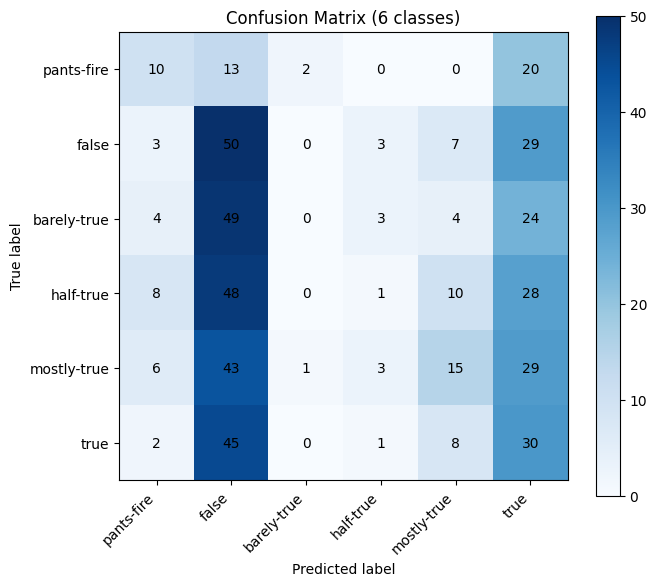

🖼️ Confusion-Matrix gespeichert unter: results/multiagent_results_5_enforcer_6_classes_Eval_confusion.png
✅ CSV mit angehängter Evaluationszeile gespeichert unter: results/multiagent_results_5_enforcer_6_classes_Eval.csv


<Figure size 640x480 with 0 Axes>

In [15]:
_ = evaluate_csv_6class_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_6_classes.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_6_classes_Eval.csv"  # optional; sonst überschreibt er die Eingabe
)


## anpassung gegen false false false true

In [ ]:
from multiagent_factcheck_5_enforcer import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator.\n"
        "IMPORTANT DEFINITIONS:\n"
        "- The claim is the exact text provided.\n"
        "- verdict == 'True' means: the claim AS WRITTEN is factually correct.\n"
        "- verdict == 'False' means: the claim AS WRITTEN is factually incorrect, unsupported, or ambiguous.\n"
        "- Never rephrase or invert the claim. Evaluate it literally.\n"
        "- Your explanation must match the verdict: if you state the claim is wrong/unsupported, verdict MUST be 'False'.\n"
        "- If experts are unanimous, follow that unless you can name a specific, verifiable source proving the opposite.\n"
        "Task:\n"
        "- Weigh reasoning quality, domain relevance, and public, verifiable evidence.\n"
        "- If evidence is insufficient/ambiguous, choose 'False'.\n"
        "Return ONLY JSON: {\"verdict\":\"True|False\",\"explanation\":\"2-4 sentences, concise\"}."
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_falsefalsefalsetrue_only_decision.csv"
)
df_res


E0000 00:00:1761459346.487034  157456 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761459346.493701  157456 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761459346.512873  157456 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761459346.512900  157456 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761459346.512902  157456 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761459346.512904  157456 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking:   0%|          | 0/500 [00:00<?, ?statement/s]

In [3]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_falsefalsefalsetrue_only_decision.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_falsefalsefalsetrue_only_decision_Eval.csv"  # optional; sonst überschreibt er die Eingabe
)



📊 Evaluation (Final Verdict)
accuracy: 0.533
precision_true: 0.740
recall_true: 0.232
f1_true: 0.353
confusion_matrix:
[57, 189]
[20, 182]

Classification report:
              precision    recall  f1-score   support

        True       0.74      0.23      0.35       246
       False       0.49      0.90      0.64       202

    accuracy                           0.53       448
   macro avg       0.62      0.57      0.49       448
weighted avg       0.63      0.53      0.48       448

✅ CSV mit angehängter Evaluationszeile gespeichert unter: results/multiagent_results_5_enforcer_falsefalsefalsetrue_only_decision_Eval.csv


In [ ]:
from multiagent_factcheck_5_enforcer import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets)."
            "IMPORTANT: verdict == 'True' means the claim AS WRITTEN is factually correct. "
            "verdict == 'False' means the claim is incorrect, unsupported, or ambiguous.\n"
            "Evaluate the claim literally. Do not invert its meaning.\n"
            "If uncertain or evidence is weak, output 'False'.\n"
            'Return ONLY JSON: {\"verdict\":\"True|False\",\"explanation\":\"2-4 sentences\",'
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely."
            "IMPORTANT: verdict == 'True' means the claim AS WRITTEN is factually correct; "
            "verdict == 'False' means the claim is incorrect, unsupported, or ambiguous.\n"
            "Evaluate the claim literally. Do not invert its meaning.\n"
            "If uncertain or evidence is weak, output 'False'.\n"
            'Return ONLY JSON: {\"verdict\":\"True|False\",\"explanation\":\"2-4 sentences\",'
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations.'
            "IMPORTANT: verdict == 'True' means the claim AS WRITTEN is factually correct; "
            "verdict == 'False' means the claim is incorrect, unsupported, or ambiguous.\n"
            "Evaluate the claim literally. Do not invert its meaning.\n"
            "If uncertain or evidence is weak, output 'False'.\n"
            'Return ONLY JSON: {\"verdict\":\"True|False\",\"explanation\":\"2-4 sentences\",'
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator.\n"
        "IMPORTANT DEFINITIONS:\n"
        "- The claim is the exact text provided.\n"
        "- verdict == 'True' means: the claim AS WRITTEN is factually correct.\n"
        "- verdict == 'False' means: the claim AS WRITTEN is factually incorrect, unsupported, or ambiguous.\n"
        "- Never rephrase or invert the claim. Evaluate it literally.\n"
        "- Your explanation must match the verdict: if you state the claim is wrong/unsupported, verdict MUST be 'False'.\n"
        "- If experts are unanimous, follow that unless you can name a specific, verifiable source proving the opposite.\n"
        "Task:\n"
        "- Weigh reasoning quality, domain relevance, and public, verifiable evidence.\n"
        "- If evidence is insufficient/ambiguous, choose 'False'.\n"
        "Return ONLY JSON: {\"verdict\":\"True|False\",\"explanation\":\"2-4 sentences, concise\"}."
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_falsefalsefalsetrue_decision_expert.csv"
)
df_res


E0000 00:00:1761585155.448250  158997 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761585155.455195  158997 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761585155.474284  158997 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761585155.474308  158997 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761585155.474310  158997 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761585155.474312  158997 computation_placer.cc:177] computation placer already registered. Please check linka

In [1]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_falsefalsefalsetrue_decision_expert.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_falsefalsefalsetrue_decision_expert_Eval.csv"  # optional; sonst überschreibt er die Eingabe
)


NameError: name 'evaluate_csv_and_append_row' is not defined

## Veränderung der Klasseneinstufungen

In [2]:
import pandas as pd

df = pd.read_csv("own_datasets/preprocessed_test_cleaned.csv", sep="\t")

# Label-Mapping definieren
label_map = {
    "true": "True",
    "mostly-true": "True",
    "half-true": "True",
    "barely-true": "True",
    "false": "False",
    "pants-fire": "False"
}

# Labels umwandeln
df["label"] = df["label"].str.strip().str.lower().map(label_map)

# Optional: Zeilen mit unbekannten Labels entfernen
df = df[df["label"].notna()]

# Kontrolle
print(df["label"].value_counts())

df.to_csv("own_datasets/test_binary_labels_pantsfire_false.csv", sep="\t", index=False)

label
True     926
False    341
Name: count, dtype: int64


In [1]:
from multiagent_factcheck_5_enforcer import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels_pantsfire_false.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_pantsfire_false.csv"
)
df_res


E0000 00:00:1761985726.617180  164314 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761985726.624037  164314 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761985726.643130  164314 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761985726.643158  164314 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761985726.643160  164314 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1761985726.643162  164314 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking: 100%|██████████| 500/500 [5:30:27<00:00, 39.66s/statement]  

✅ Ergebnisse gespeichert unter: results/multiagent_results_5_enforcer_pantsfire_false.csv

📊 Evaluation (Final Verdict)
accuracy: 0.423
precision_true: 0.789
recall_true: 0.279
f1_true: 0.412
confusion_matrix:
[101, 261]
[27, 110]
Classification report:
              precision    recall  f1-score   support

        True       0.79      0.28      0.41       362
       False       0.30      0.80      0.43       137

    accuracy                           0.42       499
   macro avg       0.54      0.54      0.42       499
weighted avg       0.65      0.42      0.42       499



,label_true,statement,subject,verdict_pred__politics,explanation__politics,verdict_pred__economy,explanation__economy,verdict_pred__health_science,explanation__health_science,verdict_pred__final_decision,explanation__final_decision,verdict_final,explanation_final
0,True,Building a wall on the U.S . Mexico border wil...,immigration,True,"In 2017, President Trump signed Executive Orde...",True,According to the U.S. Customs and Border Prote...,True,According to a 2020 report by the U.S. Governm...,True,The construction of a border wall is a complex...,True,The construction of a border wall is a complex...
1,False,Wisconsin is on pace to double the number of l...,jobs,False,"According to the Bureau of Labor Statistics, W...",False,According to the Bureau of Labor Statistics (B...,False,There is no evidence to support the claim that...,False,"Experts from politics, economy, and health_sci...",False,"Experts from politics, economy, and health_sci..."
2,False,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,John McCain has a long history of advocating f...,False,"According to the American Legion, a veterans s...",False,"John McCain, a former U.S. Senator, has a voti...",False,"Experts from politics, economy, and health_sci...",False,"Experts from politics, economy, and health_sci..."
3,True,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,Suzanne Bonamici is a U.S. Representative from...,False,According to the 2020 Medicare Trustees Report...,False,There is no evidence to suggest that Suzanne B...,False,All experts agree that Suzanne Bonamici has no...,False,All experts agree that Suzanne Bonamici has no...
4,False,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",False,There is no credible evidence to support the c...,False,There is no credible evidence to support the c...,False,There is no scientific evidence to support the...,False,"Experts from politics, economy, and health_sci...",False,"Experts from politics, economy, and health_sci..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,In one year (President Obama) provided $90 bil...,"candidates-biography,corporations,debates,ener...",True,"According to the U.S. Department of Energy, th...",False,The American Recovery and Reinvestment Act (AR...,True,"In 2009, the American Recovery and Reinvestmen...",True,The majority of experts agree that the America...,True,The majority of experts agree that the America...
496,True,Says that 98184 Texans are now driving with te...,"crime,elections,legal-issues",False,I couldn't find any information or credible so...,False,I couldn't find any reliable sources confirmin...,False,There is no credible evidence to support the c...,False,All experts agree that there is no credible ev...,False,All experts agree that there is no credible ev...
497,False,Youve been tremendously deceived by people who...,"corrections-and-updates,science,space",True,The Earth's spherical shape has been widely ac...,True,The overwhelming scientific consensus is that ...,True,The overwhelming scientific evidence supports ...,True,The overwhelming consensus among experts from ...,True,The overwhelming consensus among experts from ...
498,True,Jennifer Carrolls an outsider .,"candidates-biography,elections",False,Jennifer Carroll is a former Florida politicia...,False,Jennifer Carroll is a former Florida Deputy Se...,False,There is no credible evidence to support the c...,False,All experts agree that Jennifer Carroll is not...,False,All experts agree that Jennifer Carroll is not...


In [3]:
import pandas as pd

df = pd.read_csv("own_datasets/preprocessed_test_cleaned.csv", sep="\t")

# Label-Mapping definieren
label_map = {
    "true": "True",
    "mostly-true": "True",
    "half-true": "False",
    "barely-true": "False",
    "false": "False",
    "pants-fire": "False"
}

# Labels umwandeln
df["label"] = df["label"].str.strip().str.lower().map(label_map)

# Optional: Zeilen mit unbekannten Labels entfernen
df = df[df["label"].notna()]

# Kontrolle
print(df["label"].value_counts())

df.to_csv("own_datasets/test_binary_labels_true_mostlytrue.csv", sep="\t", index=False)

label
False    818
True     449
Name: count, dtype: int64


In [1]:
from multiagent_factcheck_5_enforcer import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels_true_mostlytrue.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_true_mostlytrue.csv"
)
df_res


E0000 00:00:1762005635.418333  168423 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762005635.425063  168423 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762005635.444137  168423 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762005635.444160  168423 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762005635.444162  168423 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762005635.444164  168423 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking: 100%|██████████| 500/500 [5:29:54<00:00, 39.59s/statement]  

✅ Ergebnisse gespeichert unter: results/multiagent_results_5_enforcer_true_mostlytrue.csv

📊 Evaluation (Final Verdict)
accuracy: 0.597
precision_true: 0.430
recall_true: 0.301
f1_true: 0.354
confusion_matrix:
[55, 128]
[73, 243]
Classification report:
              precision    recall  f1-score   support

        True       0.43      0.30      0.35       183
       False       0.65      0.77      0.71       316

    accuracy                           0.60       499
   macro avg       0.54      0.53      0.53       499
weighted avg       0.57      0.60      0.58       499



,label_true,statement,subject,verdict_pred__politics,explanation__politics,verdict_pred__economy,explanation__economy,verdict_pred__health_science,explanation__health_science,verdict_pred__final_decision,explanation__final_decision,verdict_final,explanation_final
0,True,Building a wall on the U.S . Mexico border wil...,immigration,True,"In 2017, President Trump signed Executive Orde...",True,According to the U.S. Customs and Border Prote...,True,According to a 2020 report by the U.S. Governm...,True,The construction of a border wall is a complex...,True,The construction of a border wall is a complex...
1,False,Wisconsin is on pace to double the number of l...,jobs,False,"According to the Bureau of Labor Statistics, W...",False,According to the Bureau of Labor Statistics (B...,False,There is no evidence to support the claim that...,False,"Experts from politics, economy, and health_sci...",False,"Experts from politics, economy, and health_sci..."
2,False,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,John McCain has a long history of advocating f...,False,"According to the American Legion, a veterans s...",False,"John McCain, a former U.S. Senator, has a voti...",False,"Experts from politics, economy, and health_sci...",False,"Experts from politics, economy, and health_sci..."
3,False,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,Suzanne Bonamici is a U.S. Representative from...,False,According to the 2020 Medicare Trustees Report...,False,There is no evidence to suggest that Suzanne B...,False,All experts agree that Suzanne Bonamici has no...,False,All experts agree that Suzanne Bonamici has no...
4,False,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",False,There is no credible evidence to support the c...,False,There is no credible evidence to support the c...,False,There is no scientific evidence to support the...,False,"Experts from politics, economy, and health_sci...",False,"Experts from politics, economy, and health_sci..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,In one year (President Obama) provided $90 bil...,"candidates-biography,corporations,debates,ener...",True,"According to the U.S. Department of Energy, th...",False,The American Recovery and Reinvestment Act (AR...,True,"In 2009, the American Recovery and Reinvestmen...",True,The majority of experts agree that the America...,True,The majority of experts agree that the America...
496,False,Says that 98184 Texans are now driving with te...,"crime,elections,legal-issues",False,I couldn't find any information or credible so...,False,I couldn't find any reliable sources confirmin...,False,There is no credible evidence to support the c...,False,All experts agree that there is no credible ev...,False,All experts agree that there is no credible ev...
497,False,Youve been tremendously deceived by people who...,"corrections-and-updates,science,space",True,The Earth's spherical shape has been widely ac...,True,The overwhelming scientific consensus is that ...,True,The overwhelming scientific evidence supports ...,True,The overwhelming consensus among experts from ...,True,The overwhelming consensus among experts from ...
498,False,Jennifer Carrolls an outsider .,"candidates-biography,elections",False,Jennifer Carroll is a former Florida politicia...,False,Jennifer Carroll is a former Florida Deputy Se...,False,There is no credible evidence to support the c...,False,All experts agree that Jennifer Carroll is not...,False,All experts agree that Jennifer Carroll is not...


In [4]:
import pandas as pd

df = pd.read_csv("own_datasets/preprocessed_test_cleaned.csv", sep="\t")

# Label-Mapping definieren
label_map = {
    "true": "True",
    "mostly-true": "False",
    "half-true": "False",
    "barely-true": "False",
    "false": "False",
    "pants-fire": "False"
}

# Labels umwandeln
df["label"] = df["label"].str.strip().str.lower().map(label_map)

# Optional: Zeilen mit unbekannten Labels entfernen
df = df[df["label"].notna()]

# Kontrolle
print(df["label"].value_counts())

df.to_csv("own_datasets/test_binary_labels_true.csv", sep="\t", index=False)

label
False    1059
True      208
Name: count, dtype: int64


In [ ]:
from multiagent_factcheck_5_enforcer import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels_true.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_labels_true.csv"
)
df_res


In [3]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_labels_true.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_labels_true_Eval.csv"  # optional; sonst überschreibt er die Eingabe
)



📊 Evaluation (Final Verdict)
accuracy: 0.679
precision_true: 0.211
recall_true: 0.314
f1_true: 0.252
confusion_matrix:
[27, 59]
[101, 312]

Classification report:
              precision    recall  f1-score   support

        True       0.21      0.31      0.25        86
       False       0.84      0.76      0.80       413

    accuracy                           0.68       499
   macro avg       0.53      0.53      0.52       499
weighted avg       0.73      0.68      0.70       499

✅ CSV mit angehängter Evaluationszeile gespeichert unter: results/multiagent_results_5_enforcer_labels_true_Eval.csv


## Statements vorher umschreiben

In [1]:
import os
os.environ.setdefault("TRANSFORMERS_NO_TF", "1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("TRANSFORMERS_VERBOSITY", "error")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "7")
from transformers import AutoTokenizer, AutoModelForCausalLM
import pandas as pd
from tqdm import tqdm
import re
from pathlib import Path
import torch
import csv

# ========= CONFIG =========
MODEL_ID = "meta-llama/Meta-Llama-3.1-8B-Instruct"  # bei Bedarf anpassen (z.B. 3B/70B)
INPUT_PATH = Path("own_datasets/test_binary_labels.csv")                      # <--- deine Eingabedatei
OUTPUT_PATH = Path("own_datasets/test_binary_labels_paraphrasiert.csv")       # <--- Zieldatei
SEP = "\t"                                          # TSV: "\t" | CSV: ","
BATCH_SIZE = 1                                      # 1 = einfach, >1 nur sinnvoll mit eigener Batch-Logik

GEN_KWARGS = dict(
    max_new_tokens=160,        # etwas höher, um Abschneiden zu vermeiden
    temperature=0.2,
    top_p=0.9,
    do_sample=True,
    repetition_penalty=1.05
)

SYSTEM_PROMPT = (
    "You are a careful paraphrasing assistant. "
    "Rewrite the user's sentence into one clear, fluent, neutral English sentence, "
    "preserving the original meaning precisely. "
    "Return ONLY the rewritten sentence with no quotes or extra text."
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, device_map="auto", torch_dtype="auto"
).eval()

# EOT sauber setzen (falls verfügbar)
stop_ids = [tokenizer.eos_token_id]
try:
    eot_id = tokenizer.convert_tokens_to_ids("<|eot_id|>")
    if isinstance(eot_id, int) and eot_id != -1:
        stop_ids.append(eot_id)
except Exception:
    pass

def sanitize(s: str) -> str:
    # Tabs/Zeilenumbrüche entfernen, doppelte Spaces normalisieren
    s = s.replace("\t", " ").replace("\r", " ").replace("\n", " ").strip()
    s = re.sub(r"\s{2,}", " ", s)
    return s

def paraphrase_statement(text: str) -> str:
    text = sanitize(text)
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user",   "content": text}
    ]
    inputs = tokenizer.apply_chat_template(
        messages, add_generation_prompt=True, return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        out = model.generate(
            inputs,
            eos_token_id=stop_ids,
            pad_token_id=tokenizer.eos_token_id,
            **GEN_KWARGS
        )

    # NUR neue Tokens dekodieren
    prompt_len = inputs.shape[-1]
    new_tokens = out[0][prompt_len:]
    ans = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

    # gängige Präfixe kappen + nur erste Zeile
    for p in ("Assistant:", "assistant:", "Response:", "Rewrite:", "Paraphrase:"):
        if ans.startswith(p): ans = ans[len(p):].strip()
    ans = ans.splitlines()[0].strip()
    return sanitize(ans) if ans else text

# Daten laden
df = pd.read_csv(INPUT_PATH, sep=SEP, quotechar='"', engine="python")
assert set(["label","statement","subjects"]).issubset(df.columns)

# Paraphrasieren (nur statement)
df["statement"] = [paraphrase_statement(s if isinstance(s,str) else "") for s in tqdm(df["statement"])]

# Sauber schreiben (keine All-Row-Quotes)
df.to_csv(OUTPUT_PATH, sep=SEP, index=False, quoting=csv.QUOTE_MINIMAL, lineterminator="\n")
print("Wrote:", OUTPUT_PATH)

E0000 00:00:1762328607.304655  174712 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762328607.309595  174712 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762328607.323928  174712 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762328607.323943  174712 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762328607.323945  174712 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762328607.323947  174712 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 1267/1267 [13:38<00:00,  1.55it/s]

Wrote: own_datasets/test_binary_labels_paraphrasiert.csv


In [4]:
df.to_csv(OUTPUT_PATH, sep=SEP, index=False)

In [3]:
from multiagent_factcheck_5_enforcer import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels_paraphrasiert.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_rephrasing.csv"
)
df_res


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking:   0%|          | 1/500 [00:40<5:34:13, 40.19s/statement]

KeyboardInterrupt: 

In [8]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_rephrasing.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_rephrasing_Eval.csv"  # optional; sonst überschreibt er die Eingabe
)



📊 Evaluation (Final Verdict)
accuracy: 0.500
precision_true: 0.585
recall_true: 0.345
f1_true: 0.434
confusion_matrix:
[96, 182]
[68, 154]

Classification report:
              precision    recall  f1-score   support

        True       0.59      0.35      0.43       278
       False       0.46      0.69      0.55       222

    accuracy                           0.50       500
   macro avg       0.52      0.52      0.49       500
weighted avg       0.53      0.50      0.49       500

✅ CSV mit angehängter Evaluationszeile gespeichert unter: results/multiagent_results_5_enforcer_rephrasing_Eval.csv


## experten ohne begründung

In [ ]:
from multiagent_factcheck_5_enforcer_no_reason import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_no_reason.csv"
)
df_res


E0000 00:00:1762413187.432592  175659 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762413187.439564  175659 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762413187.458340  175659 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762413187.458361  175659 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762413187.458363  175659 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762413187.458365  175659 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking:   0%|          | 1/500 [00:40<5:36:32, 40.47s/statement]

In [2]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_no_reason.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_no_reason_Eval.csv"  # optional; sonst überschreibt er die Eingabe
)



📊 Evaluation (Final Verdict)
accuracy: 0.513
precision_true: 0.657
recall_true: 0.256
f1_true: 0.369
confusion_matrix:
[71, 206]
[37, 185]

Classification report:
              precision    recall  f1-score   support

        True       0.66      0.26      0.37       277
       False       0.47      0.83      0.60       222

    accuracy                           0.51       499
   macro avg       0.57      0.54      0.49       499
weighted avg       0.58      0.51      0.47       499

✅ CSV mit angehängter Evaluationszeile gespeichert unter: results/multiagent_results_5_enforcer_no_reason_Eval.csv


# Rest

In [1]:
from multiagent_factcheck_5_enforcer import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets)"
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely"
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations;'
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality and factual grounding\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_no_falsification.csv"
)
df_res


E0000 00:00:1758000817.247362   14043 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758000817.254171   14043 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758000817.272196   14043 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1758000817.272213   14043 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1758000817.272216   14043 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1758000817.272218   14043 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking: 100%|██████████| 500/500 [6:17:22<00:00, 45.28s/statement]  

✅ Ergebnisse gespeichert unter: results/multiagent_results_5_enforcer_no_falsification.csv

📊 Evaluation (Final Verdict)
accuracy: 0.484
precision_true: 0.582
recall_true: 0.255
f1_true: 0.355
confusion_matrix:
[71, 207]
[51, 171]
Classification report:
              precision    recall  f1-score   support

        True       0.58      0.26      0.35       278
       False       0.45      0.77      0.57       222

    accuracy                           0.48       500
   macro avg       0.52      0.51      0.46       500
weighted avg       0.52      0.48      0.45       500



,label_true,statement,subject,verdict_pred__politics,explanation__politics,verdict_pred__economy,explanation__economy,verdict_pred__health_science,explanation__health_science,verdict_pred__final_decision,explanation__final_decision,verdict_final,explanation_final
0,True,Building a wall on the U.S . Mexico border wil...,immigration,True,"In 2017, the U.S. government began constructio...",True,According to the U.S. Customs and Border Prote...,True,According to a 2020 report by the U.S. Governm...,True,"Experts from politics, economy, and health_sci...",True,"Experts from politics, economy, and health_sci..."
1,False,Wisconsin is on pace to double the number of l...,jobs,False,"According to the Bureau of Labor Statistics, W...",False,According to the Bureau of Labor Statistics (B...,False,"According to the Bureau of Labor Statistics, W...",False,All experts agree that Wisconsin's unemploymen...,False,All experts agree that Wisconsin's unemploymen...
2,False,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,John McCain has a long history of advocating f...,False,"According to the American Legion, a veterans s...",False,"John McCain, a former U.S. Senator, has a voti...",False,"Experts from politics, economy, and health_sci...",False,"Experts from politics, economy, and health_sci..."
3,True,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,Suzanne Bonamici has not been found to support...,False,According to the Centers for Medicare and Medi...,False,There is no evidence to suggest that Suzanne B...,False,All three experts agree that Suzanne Bonamici ...,False,All three experts agree that Suzanne Bonamici ...
4,False,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",False,There is no credible evidence to support the c...,False,There is no credible evidence to suggest that ...,False,This claim appears to be a quote from a report...,True,Expert opinions from politics and economy agre...,True,Expert opinions from politics and economy agre...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,In one year (President Obama) provided $90 bil...,"candidates-biography,corporations,debates,ener...",True,"According to the U.S. Department of Energy, th...",False,According to the Energy Information Administra...,True,"In 2009, the American Recovery and Reinvestmen...",True,The American Recovery and Reinvestment Act of ...,True,The American Recovery and Reinvestment Act of ...
496,True,Says that 98184 Texans are now driving with te...,"crime,elections,legal-issues",False,According to the Texas Department of Public Sa...,False,According to the Texas Department of Public Sa...,False,There is no credible evidence to support the c...,False,"The claim that 98,184 Texans are driving with ...",False,"The claim that 98,184 Texans are driving with ..."
497,False,Youve been tremendously deceived by people who...,"corrections-and-updates,science,space",True,The overwhelming scientific consensus is that ...,False,The overwhelming scientific consensus is that ...,False,The Earth's shape has been extensively studied...,True,The overwhelming scientific consensus is that ...,True,The overwhelming scientific consensus is that ...
498,True,Jennifer Carrolls an outsider .,"candidates-biography,elections",False,"Jennifer Carroll, a Republican, was the Florid...",False,Jennifer Carroll is a former Florida Deputy Se...,False,There is no credible evidence to support the c...,False,Jennifer Carroll's background in public servic...,False,Jennifer Carroll's background in public servic...


In [ ]:
from multiagent_factcheck_5_enforcer import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources"
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Task: Verify the claim strictly using publicly verifiable sources"
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Task: Verify the claim strictly using publicly verifiable sources"
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality and factual grounding\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_no_falsification_no_sources.csv"
)
df_res


🔎 Fact-checking:   0%|          | 2/500 [01:21<5:36:34, 40.55s/statement]

In [1]:
import pandas as pd
from typing import Optional
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

def _normalize_labels(series: pd.Series) -> pd.Series:
    return series.astype(str).str.strip().map(
        {"True": "True", "False": "False", "true": "True", "false": "False"}
    )

def evaluate_csv_and_append_row(
    csv_path: str,
    label_col: str = "label_true",
    pred_col: str = "verdict_final",
    out_path: Optional[str] = None,
    encoding: str = "utf-8",
):
    """
    Liest eine Ergebnis-CSV ein, berechnet die Evaluation NUR für das finale Ergebnis
    (label_col vs. pred_col) und hängt eine zusätzliche Zeile mit den Kennzahlen an.
    Speichert anschließend (standardmäßig) unter dem gleichen Pfad (oder unter out_path, falls gesetzt).
    """
    df = pd.read_csv(csv_path, dtype=str, encoding=encoding)

    if label_col not in df.columns or pred_col not in df.columns:
        raise ValueError(f"Spalten nicht gefunden: '{label_col}' oder '{pred_col}' in {list(df.columns)}")

    y_true_all = _normalize_labels(df[label_col].dropna())
    y_pred_all = _normalize_labels(df[pred_col].dropna())
    idx = y_true_all.index.intersection(y_pred_all.index)
    y_true, y_pred = y_true_all.loc[idx], y_pred_all.loc[idx]

    if y_true.empty:
        print("⚠️ Keine auswertbaren Zeilen (leere Schnittmenge von Label/Pred).")
        return df

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label="True", zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label="True", zero_division=0)
    f1 = f1_score(y_true, y_pred, pos_label="True", zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=["True", "False"]).tolist()
    report = classification_report(y_true, y_pred, labels=["True", "False"], zero_division=0)

    # Konsole-Ausgabe im gewünschten Format
    print("\n📊 Evaluation (Final Verdict)")
    print(f"accuracy: {acc:.3f}")
    print(f"precision_true: {prec:.3f}")
    print(f"recall_true: {rec:.3f}")
    print(f"f1_true: {f1:.3f}")
    print("confusion_matrix:")
    for row in cm:
        print(row)
    print("\nClassification report:\n" + report)

    # Eine zusätzliche Zeile anhängen:
    # - Alle existierenden Spalten übernehmen (mit leeren Werten)
    # - Metriken in spezielle Spalten schreiben
    metrics_row = {col: "" for col in df.columns}
    metrics_row[label_col] = "__EVAL__"  # Marker in der Label-Spalte
    # Metrik-Spalten anhängen (falls nicht vorhanden, werden sie neu erstellt)
    metrics_row.update({
        "metrics_accuracy": f"{acc:.6f}",
        "metrics_precision_true": f"{prec:.6f}",
        "metrics_recall_true": f"{rec:.6f}",
        "metrics_f1_true": f"{f1:.6f}",
        "metrics_confusion_matrix": str(cm),
    })

    df_out = pd.concat([df, pd.DataFrame([metrics_row])], ignore_index=True)

    # falls neue Metrikspalten noch nicht existierten: sicherstellen, dass Reihenfolge passt
    for col in ["metrics_accuracy", "metrics_precision_true", "metrics_recall_true",
                "metrics_f1_true", "metrics_confusion_matrix"]:
        if col not in df.columns:
            # Spalte existierte nicht, dann fülle vorherige Zeilen mit Leerstring
            if col not in df_out.columns:
                df_out[col] = ""
            df_out.loc[df_out.index[-1], col] = metrics_row[col]

    out_path = out_path or csv_path
    df_out.to_csv(out_path, index=False, encoding=encoding)
    print(f"✅ CSV mit angehängter Evaluationszeile gespeichert unter: {out_path}")
    return df_out


In [2]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_no_falsification_no_sources.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_no_falsification_no_sources_eval.csv"  # optional; sonst überschreibt er die Eingabe
)



📊 Evaluation (Final Verdict)
accuracy: 0.524
precision_true: 0.630
recall_true: 0.349
f1_true: 0.449
confusion_matrix:
[97, 181]
[57, 165]

Classification report:
              precision    recall  f1-score   support

        True       0.63      0.35      0.45       278
       False       0.48      0.74      0.58       222

    accuracy                           0.52       500
   macro avg       0.55      0.55      0.52       500
weighted avg       0.56      0.52      0.51       500

✅ CSV mit angehängter Evaluationszeile gespeichert unter: results/multiagent_results_5_enforcer_no_falsification_no_sources_eval.csv


In [3]:
from multiagent_factcheck_5_enforcer import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim based on your expertise."
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Task: Verify the claim, based on your expertise."
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Task: Verify the claim based on your expertise."
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict and explanation.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality and factual grounding\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_no_falsification_no_sources_just_verify.csv"
)
df_res


E0000 00:00:1758087204.616115   21911 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758087204.622814   21911 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758087204.640888   21911 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1758087204.640918   21911 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1758087204.640920   21911 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1758087204.640922   21911 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking: 100%|██████████| 500/500 [5:49:45<00:00, 41.97s/statement]  

✅ Ergebnisse gespeichert unter: results/multiagent_results_5_enforcer_no_falsification_no_sources_just_verify.csv

📊 Evaluation (Final Verdict)
accuracy: 0.506
precision_true: 0.587
recall_true: 0.378
f1_true: 0.460
confusion_matrix:
[105, 173]
[74, 148]
Classification report:
              precision    recall  f1-score   support

        True       0.59      0.38      0.46       278
       False       0.46      0.67      0.55       222

    accuracy                           0.51       500
   macro avg       0.52      0.52      0.50       500
weighted avg       0.53      0.51      0.50       500



,label_true,statement,subject,verdict_pred__politics,explanation__politics,verdict_pred__economy,explanation__economy,verdict_pred__health_science,explanation__health_science,verdict_pred__final_decision,explanation__final_decision,verdict_final,explanation_final
0,True,Building a wall on the U.S . Mexico border wil...,immigration,True,The construction of a border wall between the ...,True,The construction of a wall along the U.S.-Mexi...,True,Building a wall on the U.S.-Mexico border is a...,True,"Experts from politics, economy, and health sci...",True,"Experts from politics, economy, and health sci..."
1,False,Wisconsin is on pace to double the number of l...,jobs,False,"According to the Bureau of Labor Statistics, W...",False,"According to the Bureau of Labor Statistics, W...",False,"According to the Bureau of Labor Statistics, W...",False,All three experts agree that Wisconsin's unemp...,False,All three experts agree that Wisconsin's unemp...
2,False,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,John McCain was a U.S. Navy pilot during the V...,False,John McCain has a long history of advocating f...,False,"John McCain, a former U.S. Navy pilot and pris...",False,"Experts from politics, economy, and health_sci...",False,"Experts from politics, economy, and health_sci..."
3,True,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,Suzanne Bonamici is a U.S. Representative from...,False,There is no information provided in the given ...,False,There is no evidence to suggest that Suzanne B...,False,Suzanne Bonamici's voting record and legislati...,False,Suzanne Bonamici's voting record and legislati...
4,False,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",False,There is no credible evidence to suggest that ...,False,The claim is likely false because the context ...,False,The claim is likely false because the statemen...,False,The claim appears to be unfounded and lacks su...,False,The claim appears to be unfounded and lacks su...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,In one year (President Obama) provided $90 bil...,"candidates-biography,corporations,debates,ener...",True,President Obama's administration provided $535...,True,The American Recovery and Reinvestment Act of ...,True,The American Recovery and Reinvestment Act of ...,True,The American Recovery and Reinvestment Act of ...,True,The American Recovery and Reinvestment Act of ...
496,True,Says that 98184 Texans are now driving with te...,"crime,elections,legal-issues",False,There is no credible information available to ...,False,There is no credible information available to ...,False,There is no credible evidence to support the c...,True,All experts agree that there is no credible in...,True,All experts agree that there is no credible in...
497,False,Youve been tremendously deceived by people who...,"corrections-and-updates,science,space",True,The overwhelming scientific consensus is that ...,True,The overwhelming scientific evidence from vari...,True,The overwhelming scientific evidence from vari...,True,The overwhelming scientific consensus confirms...,True,The overwhelming scientific consensus confirms...
498,True,Jennifer Carrolls an outsider .,"candidates-biography,elections",False,Jennifer Carroll is a former Florida politicia...,False,Jennifer Carroll is a former Florida State Rep...,False,Jennifer Carroll is a former Florida State Rep...,False,"Jennifer Carroll's background in politics, inc...",False,"Jennifer Carroll's background in politics, inc..."


# no subjects

In [1]:
from multiagent_factcheck_5_enforcer_no_subjects import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets). If evidence is "
            'insufficient or ambiguous, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely; if the data is unclear, cherry-picked, "
            'or not comparable, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations; if evidence is weak or conflicting, output "False". '
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality, factual grounding, and agreement with publicly verifiable evidence.\n"
        "- Consider the explicit weights assigned to each expert.\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        "- If the majority view (weighted) is inconclusive or poorly justified, choose 'False'.\n\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_no_subjects.csv"
)
df_res


E0000 00:00:1758261754.073696   27547 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758261754.080331   27547 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758261754.099186   27547 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1758261754.099212   27547 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1758261754.099214   27547 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1758261754.099217   27547 computation_placer.cc:177] computation placer already registered. Please check linka

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking: 100%|██████████| 500/500 [6:07:49<00:00, 44.14s/statement]  

✅ Ergebnisse gespeichert unter: results/multiagent_results_5_enforcer_no_subjects.csv

📊 Evaluation (Final Verdict)
accuracy: 0.499
precision_true: 0.625
recall_true: 0.252
f1_true: 0.359
confusion_matrix:
[70, 208]
[42, 179]
Classification report:
              precision    recall  f1-score   support

        True       0.62      0.25      0.36       278
       False       0.46      0.81      0.59       221

    accuracy                           0.50       499
   macro avg       0.54      0.53      0.47       499
weighted avg       0.55      0.50      0.46       499



,label_true,statement,verdict_pred__politics,explanation__politics,verdict_pred__economy,explanation__economy,verdict_pred__health_science,explanation__health_science,verdict_pred__final_decision,explanation__final_decision,verdict_final,explanation_final
0,True,Building a wall on the U.S . Mexico border wil...,True,"In 2017, President Trump signed Executive Orde...",True,According to the U.S. Customs and Border Prote...,True,According to the U.S. Customs and Border Prote...,True,The experts agree that building a wall on the ...,True,The experts agree that building a wall on the ...
1,False,Wisconsin is on pace to double the number of l...,False,According to the Wisconsin Department of Workf...,False,According to the Bureau of Labor Statistics (B...,False,There is no evidence to support the claim that...,False,"Experts from politics, economy, and health_sci...",False,"Experts from politics, economy, and health_sci..."
2,False,Says John McCain has done nothing to help the ...,False,John McCain was a strong advocate for veterans...,False,John McCain has been a strong advocate for vet...,False,John McCain was a U.S. Senator from Arizona wh...,False,"Experts from politics, economy, and health_sci...",False,"Experts from politics, economy, and health_sci..."
3,True,Suzanne Bonamici supports a plan that will cut...,False,Suzanne Bonamici is a U.S. Representative from...,False,"According to the Center for Medicare Advocacy,...",False,There is no evidence to suggest that Suzanne B...,False,All experts agree that Suzanne Bonamici has su...,False,All experts agree that Suzanne Bonamici has su...
4,False,When asked by a reporter whether hes at the ce...,False,There is no credible evidence to support the c...,False,There is no credible evidence to support the c...,False,This claim is about a political statement made...,False,Experts from politics and economy agree that t...,False,Experts from politics and economy agree that t...
...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,In one year (President Obama) provided $90 bil...,True,According to the U.S. Energy Information Admin...,False,The American Recovery and Reinvestment Act of ...,True,"According to the U.S. Department of Energy, th...",True,The majority of experts agree that the America...,True,The majority of experts agree that the America...
496,True,Says that 98184 Texans are now driving with te...,False,There is no publicly available information or ...,False,I couldn't find any information on the number ...,False,There is no credible evidence to support the c...,False,All experts agree that there is no credible ev...,False,All experts agree that there is no credible ev...
497,False,Youve been tremendously deceived by people who...,False,The Earth's shape has been extensively studied...,False,The overwhelming scientific consensus is that ...,True,The overwhelming scientific evidence supports ...,True,The experts' explanations are well-supported b...,True,The experts' explanations are well-supported b...
498,True,Jennifer Carrolls an outsider .,False,Jennifer Carroll is a former Florida politicia...,False,Jennifer Carroll is a former U.S. Representati...,False,There is no evidence to suggest that Jennifer ...,False,"Jennifer Carroll's background in politics, inc...",False,"Jennifer Carroll's background in politics, inc..."


In [ ]:
from multiagent_factcheck_5_enforcer_no_subjects import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources (official roll calls, bill texts, "
            "state/federal statutes, FEC/CRP filings, governor/Congress records, reputable outlets)"
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 176,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Verify using BLS, BEA, CBO, JCT, Treasury/IRS, OMB, and credible international sources "
            "(IMF/World Bank/WTO). Define metrics and time ranges precisely"
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 184,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Verify with CDC, FDA, NIH, CMS, WHO, Cochrane, and peer-reviewed literature (PubMed). Distinguish "
            'correlation vs. causation and specify years/locations;'
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality and factual grounding\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_no_falsification_no_subjects.csv"
)
df_res


🔎 Fact-checking:   0%|          | 1/500 [00:46<6:26:38, 46.49s/statement]

In [4]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_no_falsification_no_subjects.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_no_falsification_no_subjects_eval.csv"  # optional; sonst überschreibt er die Eingabe
)



📊 Evaluation (Final Verdict)
accuracy: 0.473
precision_true: 0.570
recall_true: 0.206
f1_true: 0.302
confusion_matrix:
[57, 220]
[43, 179]

Classification report:
              precision    recall  f1-score   support

        True       0.57      0.21      0.30       277
       False       0.45      0.81      0.58       222

    accuracy                           0.47       499
   macro avg       0.51      0.51      0.44       499
weighted avg       0.52      0.47      0.42       499

✅ CSV mit angehängter Evaluationszeile gespeichert unter: results/multiagent_results_5_enforcer_no_falsification_no_subjects_eval.csv


In [5]:
from multiagent_factcheck_5_enforcer_no_subjects import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim strictly using publicly verifiable sources"
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Task: Verify the claim strictly using publicly verifiable sources"
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Task: Verify the claim strictly using publicly verifiable sources"
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality and factual grounding\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_no_falsification_no_sources_no_subjects.csv"
)
df_res


🔎 Fact-checking: 100%|██████████| 500/500 [6:12:14<00:00, 44.67s/statement]  

✅ Ergebnisse gespeichert unter: results/multiagent_results_5_enforcer_no_falsification_no_sources_no_subjects.csv

📊 Evaluation (Final Verdict)
accuracy: 0.488
precision_true: 0.579
recall_true: 0.292
f1_true: 0.388
confusion_matrix:
[81, 196]
[59, 162]
Classification report:
              precision    recall  f1-score   support

        True       0.58      0.29      0.39       277
       False       0.45      0.73      0.56       221

    accuracy                           0.49       498
   macro avg       0.52      0.51      0.47       498
weighted avg       0.52      0.49      0.46       498



,label_true,statement,verdict_pred__politics,explanation__politics,verdict_pred__economy,explanation__economy,verdict_pred__health_science,explanation__health_science,verdict_pred__final_decision,explanation__final_decision,verdict_final,explanation_final
0,True,Building a wall on the U.S . Mexico border wil...,True,According to a 2020 report by the Government A...,True,According to the U.S. Customs and Border Prote...,True,According to the U.S. Customs and Border Prote...,True,The construction of a border wall is a complex...,True,The construction of a border wall is a complex...
1,False,Wisconsin is on pace to double the number of l...,False,"According to the Bureau of Labor Statistics, W...",False,"According to the Bureau of Labor Statistics, W...",False,"According to the Bureau of Labor Statistics, W...",False,All experts agree that Wisconsin's unemploymen...,False,All experts agree that Wisconsin's unemploymen...
2,False,Says John McCain has done nothing to help the ...,False,John McCain was a strong advocate for veterans...,False,John McCain was a strong supporter of veterans...,False,John McCain was a United States Senator from A...,False,"Experts from politics, economy, and health_sci...",False,"Experts from politics, economy, and health_sci..."
3,True,Suzanne Bonamici supports a plan that will cut...,False,Suzanne Bonamici is a U.S. Representative from...,False,According to the American Association of Retir...,False,"According to the Center for Medicare Advocacy,...",False,All three experts agree that Suzanne Bonamici ...,False,All three experts agree that Suzanne Bonamici ...
4,False,When asked by a reporter whether hes at the ce...,False,There is no credible evidence to support the c...,False,According to a report by the Milwaukee Journal...,False,According to a report by the Milwaukee Journal...,False,The claim that Gov. Scott Walker nodded yes wh...,False,The claim that Gov. Scott Walker nodded yes wh...
...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,In one year (President Obama) provided $90 bil...,True,According to the U.S. Energy Information Admin...,False,According to the U.S. Energy Information Admin...,False,According to the U.S. Energy Information Admin...,False,The U.S. Energy Information Administration con...,False,The U.S. Energy Information Administration con...
496,True,Says that 98184 Texans are now driving with te...,False,According to the Texas Department of Public Sa...,False,According to the Texas Department of Public Sa...,False,According to the Texas Department of Public Sa...,False,All experts agree that temporary driver's lice...,False,All experts agree that temporary driver's lice...
497,False,Youve been tremendously deceived by people who...,True,The overwhelming scientific consensus is that ...,False,The overwhelming scientific evidence supports ...,True,The overwhelming scientific evidence supports ...,True,The overwhelming scientific consensus is that ...,True,The overwhelming scientific consensus is that ...
498,True,Jennifer Carrolls an outsider .,False,Jennifer Carroll is a former Florida State Rep...,False,Jennifer Carroll is a former Comptroller of th...,False,Jennifer Carroll is a former Texas Comptroller...,False,"Jennifer Carroll's background in politics, inc...",False,"Jennifer Carroll's background in politics, inc..."


In [ ]:
from multiagent_factcheck_5_enforcer_no_subjects import process_claims_multi_experts

experts_cfg = [
    {
        "name": "politics",
        "system": (
            "You are a subject-matter expert in U.S. politics, elections, legislation, and public records. "
            "Task: Verify the claim based on your expertise."
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
    {
        "name": "economy",
        "system": (
            "You are a subject-matter expert in macroeconomics, labor statistics, public budgets, and taxation. "
            "Task: Verify the claim, based on your expertise."
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
    {
        "name": "health_science",
        "system": (
            "You are a subject-matter expert in healthcare policy, public health, and scientific evidence appraisal. "
            "Task: Verify the claim based on your expertise."
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict and explanation.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality and factual grounding\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_no_falsification_no_sources_just_verify_no_subjects.csv"
)
df_res


🔎 Fact-checking:   0%|          | 2/500 [01:38<6:46:49, 49.02s/statement]

In [10]:
_ = evaluate_csv_and_append_row(
    csv_path="results/multiagent_results_5_enforcer_no_falsification_no_sources_just_verify_no_subjects.csv",   # deine Ergebnis-CSV
    label_col="label_true",
    pred_col="verdict_final",
    out_path="results/multiagent_results_5_enforcer_no_falsification_no_sources_just_verify_no_subjects_eval.csv"  # optional; sonst überschreibt er die Eingabe
)



📊 Evaluation (Final Verdict)
accuracy: 0.518
precision_true: 0.608
recall_true: 0.374
f1_true: 0.463
confusion_matrix:
[104, 174]
[67, 155]

Classification report:
              precision    recall  f1-score   support

        True       0.61      0.37      0.46       278
       False       0.47      0.70      0.56       222

    accuracy                           0.52       500
   macro avg       0.54      0.54      0.51       500
weighted avg       0.55      0.52      0.51       500

✅ CSV mit angehängter Evaluationszeile gespeichert unter: results/multiagent_results_5_enforcer_no_falsification_no_sources_just_verify_no_subjects_eval.csv


# Andere Experten (nicht fachlich)

In [3]:
from multiagent_factcheck_5_enforcer import process_claims_multi_experts
experts_cfg = [
    {
        "name": "rhetoric_style",
        "system": (
            "You are a subject-matter expert for rhetoric, persuasive language, and discourse analysis. "
            "Task: Analyze the claim's language for rhetorical devices (absolutism, hyperbole, sarcasm, emotionally loaded terms, false balance) and assess whether the statement relies mainly on rhetoric rather than verifiable evidence. "
            "If the claim relies mainly on rhetoric without verifiable evidence, output 'False'. If rhetoric is minimal and a factual basis is present, do not penalize. "
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
    {
        "name": "logic_reasoning",
        "system": (
            "You are a subject-matter expert in logic, reasoning fallacies, and argumentation theory. "
            "Task: Determine whether the claim is logically consistent, checking for contradictions, overgeneralizations from single events, tautologies, circular reasoning, and false cause/effect. "
            "If the claim is logically unsound or cannot be generalized, output 'False'. "
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
    {
        "name": "knowledge_type",
        "system": (
            "You are a subject-matter expert in epistemology: distinguishing factual claims from opinions or unverifiable assertions. "
            "Task: Classify whether the claim is a checkable fact with objective evidence, a subjective opinion, or ambiguous/context-dependent. "
            "If the claim is opinion, unverifiable, or ambiguous, output 'False'. If it is clearly checkable as fact, output 'True'. "
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
    {
        "name": "verifiability",
        "system": (
            "You are a subject-matter expert for claim verifiability. "
            "Task: Judge whether the claim is formulated so it can be independently verified by evidence, with specific and measurable criteria. "
            "If the claim is vague, lacks measurable criteria, or is non-falsifiable opinion, output 'False'. If specific, factual, and checkable, output 'True'. "
            'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
            'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
        ),
        "model_id": "meta-llama/Llama-3.1-8B-Instruct",
        "max_new_tokens": 192,
    },
]

decision_cfg = {
    "name": "final_decision",
    "system": (
        "You are a senior fact-checking adjudicator. You receive multiple expert analyses, "
        "each with a verdict, explanation, and weight.\n\n"
        "Task:\n"
        "- Evaluate the experts' reasoning quality and factual grounding\n"
        "- Prioritize well-supported, domain-relevant arguments over unsupported or vague statements.\n"
        'Return ONLY a JSON object with fields: {"verdict":"True|False","explanation":"2-4 concise sentences, '
        'no stepwise reasoning or lists"}. No markdown, no preface, no code fences, no extra keys.'
    ),
    "model_id": "meta-llama/Llama-3.1-8B-Instruct",
    "max_new_tokens": 192,
}


df_res = process_claims_multi_experts(
    csv_path="own_datasets/test_binary_labels.csv",
    experts_cfg=experts_cfg,
    nrows=500,
    default_model_id="meta-llama/Llama-3.1-8B-Instruct",
    show_progress=True,
    decision_cfg=decision_cfg,
    save_path="results/multiagent_results_5_enforcer_no_falsification_other_experts.csv"
)
df_res


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

🔎 Fact-checking: 100%|██████████| 500/500 [6:39:46<00:00, 47.97s/statement]  

✅ Ergebnisse gespeichert unter: results/multiagent_results_5_enforcer_no_falsification_other_experts.csv

📊 Evaluation (Final Verdict)
accuracy: 0.568
precision_true: 0.658
recall_true: 0.464
f1_true: 0.544
confusion_matrix:
[129, 149]
[67, 155]
Classification report:
              precision    recall  f1-score   support

        True       0.66      0.46      0.54       278
       False       0.51      0.70      0.59       222

    accuracy                           0.57       500
   macro avg       0.58      0.58      0.57       500
weighted avg       0.59      0.57      0.56       500



,label_true,statement,subject,verdict_pred__rhetoric_style,explanation__rhetoric_style,verdict_pred__logic_reasoning,explanation__logic_reasoning,verdict_pred__knowledge_type,explanation__knowledge_type,verdict_pred__verifiability,explanation__verifiability,verdict_pred__final_decision,explanation__final_decision,verdict_final,explanation_final
0,True,Building a wall on the U.S . Mexico border wil...,immigration,False,"The claim uses hyperbole, exaggerating the tim...",True,The claim is based on a single event or instan...,True,This claim is verifiable through historical da...,True,The claim is verifiable as it refers to a spec...,True,Expert knowledge_type's explanation is well-su...,True,Expert knowledge_type's explanation is well-su...
1,False,Wisconsin is on pace to double the number of l...,jobs,False,The claim relies on a vague and relative term ...,False,The claim is based on a single event or a proj...,True,This claim can be verified through economic da...,False,The claim is too vague to be independently ver...,False,"The claim relies on vague and relative terms, ...",False,"The claim relies on vague and relative terms, ..."
2,False,Says John McCain has done nothing to help the ...,"military,veterans,voting-record",False,"This claim relies on absolutism, implying that...",False,This claim is likely based on a single event o...,False,This claim is subjective and based on personal...,False,"The claim is subjective and lacks specific, me...",False,Experts agree that the claim is an exaggeratio...,False,Experts agree that the claim is an exaggeratio...
3,True,Suzanne Bonamici supports a plan that will cut...,"medicare,message-machine-2012,campaign-adverti...",False,The claim uses emotionally loaded terms like '...,False,The claim is based on a single event (message-...,True,This claim can be verified through publicly av...,False,The claim is too vague to be independently ver...,False,Expert knowledge_type's explanation is well-su...,False,Expert knowledge_type's explanation is well-su...
4,False,When asked by a reporter whether hes at the ce...,"campaign-finance,legal-issues,campaign-adverti...",False,The claim relies heavily on emotionally loaded...,False,This claim is likely an example of a false cau...,False,This claim is likely an opinion or unverifiabl...,False,The claim is too vague and lacks specific deta...,False,The claim relies on an unverifiable interpreta...,False,The claim relies on an unverifiable interpreta...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,False,In one year (President Obama) provided $90 bil...,"candidates-biography,corporations,debates,ener...",False,"The claim relies on absolutism and hyperbole, ...",True,The claim is based on a single event and speci...,True,The claim refers to the American Recovery and ...,True,The claim can be verified by checking the annu...,False,Experts' explanations suggest that the claim r...,False,Experts' explanations suggest that the claim r...
496,True,Says that 98184 Texans are now driving with te...,"crime,elections,legal-issues",False,The claim relies heavily on rhetoric as it use...,False,This claim is likely based on a single event o...,False,This claim is likely an opinion or unverifiabl...,False,The claim lacks specific and measurable criter...,False,The claim relies heavily on unverifiable infor...,False,The claim relies heavily on unverifiable infor...
497,False,Youve been tremendously deceived by people who...,"corrections-and-updates,science,space",False,The claim relies heavily on emotionally loaded...,False,The claim is based on an assumption that peopl...,True,The Earth's shape has been extensively studied...,True,This claim can be verified by checking the ove...,True,The Earth's shape has been extensively studied...,True,The Earth's shape has been extensively studied...
498,True,Jennifer Carrolls an outsider .,"candidates-biography,elections",False,The claim 'Jennifer Carrolls an outsider' is a...,False,The claim that Jennife

In [2]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# ===== Helper: Label-Normalisierung =====
def _normalize_labels(series: pd.Series):
    """Bringt Labels in {'True','False'}-Strings; ignoriert NaN."""
    return series.astype(str).str.strip().map(
        {"True": "True", "False": "False", "true": "True", "false": "False"}
    )

def compute_binary_metrics(df: pd.DataFrame, label_col: str, pred_col: str):
    y_true_all = _normalize_labels(df[label_col].dropna())
    y_pred_all = _normalize_labels(df[pred_col].dropna())
    idx = y_true_all.index.intersection(y_pred_all.index)
    y_true, y_pred = y_true_all.loc[idx], y_pred_all.loc[idx]

    if y_true.empty:
        return None

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_true": precision_score(y_true, y_pred, pos_label="True", zero_division=0),
        "recall_true": recall_score(y_true, y_pred, pos_label="True", zero_division=0),
        "f1_true": f1_score(y_true, y_pred, pos_label="True", zero_division=0),
        "n_eval": len(idx),
    }

# ===== Main =====
def evaluate_experts(csv_path: str):
    df = pd.read_csv(csv_path)

    # Alle Spalten finden, die mit "verdict_pred__" beginnen
    expert_cols = [c for c in df.columns if c.startswith("verdict_pred__")]
    results = []

    for col in expert_cols:
        metrics = compute_binary_metrics(df, "label_true", col)
        if metrics:
            results.append({
                "expert": col.replace("verdict_pred__", ""),
                **metrics
            })

    # Ergebnisse als DataFrame ausgeben
    results_df = pd.DataFrame(results)
    print("\n📊 Experten-Evaluation")
    print(results_df.to_string(index=False, float_format="%.3f"))
    return results_df

# ===== Beispielaufruf =====
if __name__ == "__main__":
    results_df = evaluate_experts("results/multiagent_results_5_enforcer_no_falsification_other_experts.csv")



📊 Experten-Evaluation
         expert  accuracy  precision_true  recall_true  f1_true  n_eval
 rhetoric_style     0.510           0.720        0.194    0.306     500
logic_reasoning     0.510           0.663        0.241    0.354     500
 knowledge_type     0.604           0.627        0.709    0.666     500
  verifiability     0.566           0.645        0.489    0.556     500
 final_decision     0.568           0.658        0.464    0.544     500
